In [18]:
import os #检查文件是否存在
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import matplotlib
from matplotlib.collections import LineCollection
from matplotlib.colors import hsv_to_rgb
from scipy.signal import savgol_filter

import tkinter as tk
from tkinter import filedialog
from math import*

def Distance(pos1:list, pos2:list) -> float:
    return sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

root = tk.Tk()
root.withdraw()

mouseNames:list[str] = []
LogsFolders:list[str] = []
configs = []

All_folder_paths = "2_19to3_4Logs"
if All_folder_paths == "":
    All_folder_paths = filedialog.askdirectory(initialdir = os.getcwd(), title="选择包含指定批次Log数据的文件夹")
if not All_folder_paths:
    exit()

# 遍历每个选择的文件夹
for folder_path in os.listdir(All_folder_paths):
    if not folder_path.startswith("#") and os.path.isdir(os.path.join(All_folder_paths, folder_path)):
        mouseNames.append(folder_path)
        LogsFolders.append(os.path.join(All_folder_paths, folder_path))
    elif os.path.isfile(os.path.join(All_folder_paths, folder_path)):
        mouseNames.append(All_folder_paths)
        LogsFolders.append(All_folder_paths)
        break


recfileList = []
posfileList = []
limitedColumns = ['type', 'delta time', 'mode', 'trial', 'lickPos', 'result']
for mouseIndex in LogsFolders:
    recfileList.append([])
    posfileList.append([])
    for file in os.listdir(mouseIndex):
        if file.endswith("rec.txt"):    
            recfileList[-1].append(file)
        elif file.endswith("pos.txt"):
            posfileList[-1].append(file)
    recfileList[-1].sort()
    posfileList[-1].sort()

def readToDataRows(_fname, _dataRows, _addtion:list = None):
    _config = ""
    with open(_fname, 'r') as file:
        for line in file:
            if line.strip() and "\t" in line:
                if line.count("\t") >= 4:
                # 按制表符分割行，并添加到数据行列表中
                    _dataRows.append(line.strip().split('\t')[0:len(limitedColumns)])
                #if len(dataRows) > 1:
                    #dataRows[-1][1] = float(dataRows[-1][1])
                #dataRowsTyped.append(dataRows[-1])
            elif line.startswith("{"):
                _config += line + "\n"
            if _addtion is not None:
                if "Trial initialized" in line:
                    _addtion.clear()
                if "started at " in line:
                    _addtion.append(line[line.index("started at "):line.index("started at ") + 1])

    return _config

AllMouseRecMainDfs = []
AllMousePosMainDfs = []
AllMouseAddLs = []
sceneinfo = None
selectedArea = []
def IsValidPosLine(tempDfValue:pd.Series) -> bool:
    if len(tempDfValue) == 6:
        try:
            _y = int(tempDfValue['y'])
            int(tempDfValue['frameInd'])
            _t = float(tempDfValue['TimeInUnitySecFromTrialStart'])
        
            if _y in [0, 1] and int(_t) in [0, 1]:
                return False
            else:
                return True
        except:
            return False
    return False
for mouseIndex in range(0, len(recfileList)):#fileList按mouse排序
    AllMouseRecMainDfs.append([])
    AllMousePosMainDfs.append([])
    AllMouseAddLs.append([])
    configs.append([])
    for DailyRecord in recfileList[mouseIndex]:
        _datarows = []
        _config = readToDataRows(LogsFolders[mouseIndex] + "/" + DailyRecord, _datarows, AllMouseAddLs[mouseIndex])
        configs[-1].append(_config)

        nowDf = pd.DataFrame(_datarows, columns=limitedColumns)
        nowDf = nowDf.drop(nowDf.index[nowDf['type'] == "type"])
        nowDf['delta time'] = np.float64(nowDf['delta time'])

        AllMouseRecMainDfs[-1].append(nowDf)

    for DailyPos in posfileList[mouseIndex]:
        _datarows = []
        
        nowDf = pd.read_csv(LogsFolders[mouseIndex] + "/" + DailyPos,sep='\t',names=['x','y', 'syncInd', "100*pythonTime", "frameInd", "TimeInUnitySecFromTrialStart"], dtype=str)
        while not IsValidPosLine(nowDf.iloc[0].astype(str)):
            if nowDf.iloc[0].isnull().sum() == 2:
                sceneinfo = nowDf.iloc[0].astype(float, errors='ignore').values
                if type(sceneinfo[0]) == str:
                    sceneinfo = []
            else:
                try:
                    tempAreaLs = tuple(nowDf.iloc[0].astype(int).values)
                    if tempAreaLs not in selectedArea:
                        selectedArea.append(tempAreaLs)
                except:
                    pass
            nowDf = nowDf.iloc[1:]

        nowDf = nowDf.drop_duplicates(subset='syncInd', keep='first')
        nowDf.loc[:,'x':'frameInd'] = nowDf.loc[:,'x':'frameInd'].astype(int)
        nowDf['TimeInUnitySecFromTrialStart'] = nowDf['TimeInUnitySecFromTrialStart'].astype(float)
        nowDf.index = np.array(range(0, len(nowDf)))
        AllMousePosMainDfs[-1].append(nowDf)
            

In [ ]:
# def SmoothTrack(Df):
#     x = Df['x'].values.astype(int)
#     y = Df['y'].values.astype(int)

#     distancesToCenter = np.sqrt((x - sceneinfo[0])**2 + (y  - sceneinfo[1])**2)
#     # 创建掩码，排除首行
#     mask = distancesToCenter < sceneinfo[2]
#     mask[0] = True
#     Df['smooth_x'] = Df['x'].where(mask).ffill()
#     Df['smooth_y'] = Df['y'].where(mask).ffill()

#     window_size = 7  # 根据实际情况调整
#     tempx = Df['smooth_x'].rolling(window_size, center=True, min_periods=1).median()
#     tempy = Df['smooth_y'].rolling(window_size, center=True, min_periods=1).median()

#     # 2. 轨迹平滑（Savitzky-Golay滤波器）
#     window_length = 15  # 必须为奇数，根据实际情况调整
#     polyorder = 3       # 多项式阶数
#     Df['smooth_x'] = savgol_filter(tempx, window_length, polyorder)
#     Df['smooth_y'] = savgol_filter(tempy, window_length, polyorder)
#     print("Track smoothed.")

In [26]:
ignoreFristTrials = 20
ignoreLastTrials = 20
maxTrials = ignoreFristTrials + 350

global trialGroupCount, trialPerGroup
trialGroupCount= 4
trialPerGroup = 100

class Day:
    def __init__(self, _RecMainDf, _PosMainDf, _name, _day):
        self.trials                  :list[pd.DataFrame]= []
        self.startIndices            = []
        self.EndIndices              = []
        self.licks                   = []
        self.licksPos                :list= []
        self.lickInterval            :list= []
        self.lickIntervalLog         :list= []
        self.trialResults            :list= []
        self.trialElapsedTime        :list= []
        self.trialIntervalTime       :list= []
        self.trialAccuracyInGroup    :list= []
        self.trialElapsedTimeInGroup :list= []
        self.trialIntervalInGroup    :list= []
        
        self.posPerTrial             :list= []
        self.posSegPerTrial          :list= []
        self.speedPerTrial           :list= []
        self.fuDistancePerTrial:list= []
        self.uDistancePerTrial    :list= []
        self.DistancePerTrial        :list= []
        self.trialMark               :list= []

        self.RecMainDf:pd.DataFrame = _RecMainDf
        self.PosMainDf:pd.DataFrame = _PosMainDf
        # self.RecMainDfClear:pd.DataFrame = _RecMainDf
        self.PosMainDfClear:pd.DataFrame = None
        self.trialPerGroup = -1
        self.day = _day
        self.name = _name

    def Process(self): 
        print("Processing mouse " + self.name + " day " + str(self.day))
        init = self.RecMainDf.index[self.RecMainDf['type'] == "init"]
        if (len(init)):
            init = max(init)
        else:
            init = 0
        self.RecMainDf = self.RecMainDf[init:]

        self.startIndices    =          self.RecMainDf.index[self.RecMainDf['type'] == "start"]#trial处理均以开始结束Index为标准
        self.EndIndices      =          self.RecMainDf.index[self.RecMainDf['type'] == "end"]
        self.licks           = np.array(self.RecMainDf.loc[self.RecMainDf["type"] == "lick"]["delta time"])
        self.startIndices.delete(range(len(self.EndIndices), len(self.startIndices)))

        self.PosMainx = []
        self.PosMainy = []
        self.SmoothTrack()  #add 'x_smooth' and 'y_smooth' columns to PosMainDf

        dt = np.gradient(self.PosMainDf['TimeInUnitySecFromTrialStart'])  # 使用梯度处理非均匀时间戳
        dx = np.gradient(self.PosMainDf['smooth_x'])
        dy = np.gradient(self.PosMainDf['smooth_y'])
        unitDistance = np.sqrt((dx)**2 + (dy)**2)
        speed = np.sqrt((dx/dt)**2 + (dy/dt)**2)
        self.PosMainDf['speed'] = speed
        self.PosMainDf['unitDistance'] = unitDistance
        self.PosMainDf['elaspedtime'] = self.PosMainDf['TimeInUnitySecFromTrialStart'] - self.PosMainDf['TimeInUnitySecFromTrialStart'].shift(1)
        self.PosMainDf.loc[0, 'elaspedtime'] = 0
        # time = self.PosMainDf.loc[(self.PosMainDf['elaspedtime'] > 0.5) | (self.PosMainDf['unitDistance'] > 40),'TimeInUnitySecFromTrialStart']
        time = self.PosMainDf.loc[self.PosMainDf['unitDistance'] > 40,'TimeInUnitySecFromTrialStart']

        self.PosMainDfClear = pd.DataFrame.copy(self.PosMainDf, deep=True)
        # DrawTrack(self.PosMainDf['x'].values, self.PosMainDf['y'].values, unitDistance, title = "orogin track")
        # plt.hist(unitDistance, bins=10, alpha=0.5, density=False, rwidth= 0.9, label='step distance')
        # DrawTrack(self.PosMainDf['smooth_x'].values, self.PosMainDf['smooth_y'].values, unitDistance, title = "smoothed track")        
        popOffset = 0
        segment = []
        fristIgnoredTrials = 0
        lastIgnoredTrials = 0
        for i in range(1, len(self.EndIndices)):
            _i = i - popOffset
            self.trials.append(     self.RecMainDf.loc[self.startIndices[i-1] : self.startIndices[i], :])
            tempResult:int = int(   self.RecMainDf.loc[self.EndIndices[     i - 1]]["result"])
            tempStartTime   =       self.RecMainDf.loc[self.startIndices[   i - 1]]['delta time']
            tempTrackStartTime   =  self.RecMainDf.loc[self.EndIndices[     i - 2]]['delta time'] if i > 1 else self.RecMainDf.loc[self.startIndices[   i - 1]]['delta time']
            tempEndTime     =       self.RecMainDf.loc[self.EndIndices[     i - 1]]['delta time']
            
            tempDf = self.trials[-1]

            if self.CheckTrialIntegrity(tempDf) and tempResult >= 0 and not time.between(tempStartTime, tempEndTime, inclusive='both').any():
                self.licksPos.append(           self.RecMainDf.loc[self.EndIndices  [i - 1] - 1]["lickPos"])
                self.trialResults.append(       self.RecMainDf.loc[self.EndIndices  [i - 1]]["result"])
                self.trialElapsedTime.append(   self.RecMainDf.loc[self.EndIndices  [i-1]]['delta time'] - self.RecMainDf.loc[self.startIndices[i-1]]['delta time'])
                self.trialIntervalTime.append(  self.RecMainDf.loc[self.startIndices[i]]['delta time'] - self.RecMainDf.loc[self.EndIndices[i-1]]['delta time'])
                self.posPerTrial.append(self.PosMainDf.loc[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime), :])
                self.posSegPerTrial.append(self.SpeedSegment(self.posPerTrial[_i-1]['speed'], self.posPerTrial[_i-1]))
                self.speedPerTrial.append(speed[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]])
                self.fuDistancePerTrial.append(     unitDistance[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]])
                self.uDistancePerTrial.append(   unitDistance[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]])
                self.DistancePerTrial.append(np.sum(self.uDistancePerTrial[-1]))

                tempStayTime = tempDf.loc[tempDf['type'] == 'stay']['delta time'].values[0]
                self.trialMark.append([self.GetPosAtTime(tempStayTime - 0.5), self.GetPosAtTime(tempStayTime - 0.25)])
                # if self.day >=3:
                #     DrawTrack(self.posPerTrial[-1]['smooth_x'].values, self.posPerTrial[-1]['smooth_y'].values, self.unitDistancePerTrial[-1], addInfo=f'{self.name}_{self.day}_{np.sum(self.unitDistancePerTrial[-1])/sceneinfo[2]:.2f}_trial{i}', show=False, save=True, lw=0.6, pointSize=0.3)
                # DrawTrack(self.posPerTrial[-1]['smooth_x'].values, self.posPerTrial[-1]['smooth_y'].values, addInfo=f'Level{np.sum(self.unitDistancePerTrial[-1])//2500}_{self.name}_{self.day}_{i - 1}', show=False, save=True)
                
            else:
                posDfDropIndexes = self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]
                segment.append(posDfDropIndexes[0])
                self.trials.pop()
                self.PosMainDfClear = self.PosMainDfClear.drop(posDfDropIndexes)
                popOffset += 1
                if i < ignoreFristTrials:
                    fristIgnoredTrials += 1
                elif i > len(self.EndIndices) - ignoreLastTrials:
                    lastIgnoredTrials += 1
                # tempDf = self.PosMainDf.loc[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime), :]
                # DrawTrack(tempDf['smooth_x'].values, tempDf['smooth_y'].values, unitDistance[self.PosMainDf.index[(self.PosMainDf['TimeInUnitySecFromTrialStart'] >= tempTrackStartTime) & (self.PosMainDf['TimeInUnitySecFromTrialStart'] <= tempEndTime)]], addInfo=f'abnormal_{self.name}_{self.day}_{i}', show=False, save=True)
            
        # DrawTrack(self.PosMainDfClear['smooth_x'].values, self.PosMainDfClear['smooth_y'].values, unitDistance[self.PosMainDfClear.index], segment=segment, title = "smoothed track", save=True, addInfo=f'{self.name}_{self.day}')        
        fullTrialCount = len(self.trials)
        self.trials             = self.trials[              ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.licksPos           = self.licksPos[            ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.trialResults       = self.trialResults[        ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.trialElapsedTime   = self.trialElapsedTime[    ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.trialIntervalTime  = self.trialIntervalTime[   ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.posPerTrial        = self.posPerTrial[         ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.posSegPerTrial     = self.posSegPerTrial[      ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.speedPerTrial      = self.speedPerTrial[       ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.fuDistancePerTrial = self.fuDistancePerTrial[  ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.uDistancePerTrial = self.uDistancePerTrial[  ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.DistancePerTrial = self.DistancePerTrial[  ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]
        self.trialMark          = self.trialMark[           ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, maxTrials)]

        self.trialResults = np.int8(self.trialResults)
        self.licksPos = np.int8(self.licksPos)

        self.lickInterval       = self.licks[1:] - self.licks[0: -1]
        self.lickInterval       = self.lickInterval[self.lickInterval > 0]
        self.lickIntervalLog    = np.log(1/self.lickInterval)

        if(trialGroupCount > 0):
            self.trialPerGroup = max(1, ceil(len(self.trials)/trialGroupCount))
        else:
            self.trialPerGroup = trialPerGroup

        for i in range(0, ceil(len(self.trialResults) / self.trialPerGroup)):
            self.trialAccuracyInGroup.append(   np.sum(self.trialResults[       i * self.trialPerGroup:  min(len(self.trialResults)      , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.trialResults) - i * self.trialPerGroup))
            self.trialElapsedTimeInGroup.append(np.sum(self.trialElapsedTime[   i * self.trialPerGroup:  min(len(self.trialElapsedTime)  , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.trialResults) - i * self.trialPerGroup))
            self.trialIntervalInGroup.append(   np.sum(self.trialIntervalTime[  i * self.trialPerGroup:  min(len(self.trialIntervalTime) , (i + 1) * self.trialPerGroup)]) / min(self.trialPerGroup, len(self.trialResults) - i * self.trialPerGroup))

        self.trialElapsedTimeMean    = np.mean(self.trialElapsedTime)
        self.trialIntervalTimeMean   = np.mean(self.trialIntervalTime)

        # plt.hist(self.trialElapsedTime, range=(0, 120), bins=10, alpha=0.5, density=True, rwidth= 0.9, label='Trial Elapsed Time')

        print("Day " + str(self.day) + " processed.")

    def CheckTrialIntegrity(self, tempDf:pd.DataFrame) -> bool:
        essentialTypes = ['stay']
        for essentialType in essentialTypes:
            if essentialType not in tempDf['type'].values:
                return False
        return True

    def GetPosAtTime(self, time, df = None):
        if df is None:
            df = self.PosMainDf

        indexs = df.index[df['TimeInUnitySecFromTrialStart'] <= time]
        if len(indexs):
            return df.iloc[np.max(indexs)]['x':'y']
        else:
            return df.iloc[0]['x':'y']
    
    def SpeedSegment(self, speedArray, posDf):
        speed_threshold = np.nanmean(speedArray) / 3
        low_speed_mask = speedArray < speed_threshold

        # 创建分段
        segments = []
        current_segment = []
        for i, is_low in enumerate(low_speed_mask):
            if not is_low:
                current_segment.append(i)
            else:
                if current_segment:
                    segments.append(posDf.iloc[current_segment])
                    current_segment = []
        if current_segment:
            segments.append(posDf.iloc[current_segment])
        return segments
    
    def SmoothTrack(self):
        x = self.PosMainDf['x'].values.astype(int)
        y = self.PosMainDf['y'].values.astype(int)

        distancesToCenter = np.sqrt((x - sceneinfo[0])**2 + (y  - sceneinfo[1])**2)
        # 创建掩码，排除首行
        mask = distancesToCenter < sceneinfo[2]
        mask[0] = True
        self.PosMainDf['smooth_x'] = self.PosMainDf['x'].where(mask).ffill()
        self.PosMainDf['smooth_y'] = self.PosMainDf['y'].where(mask).ffill()

        window_size = 7  # 根据实际情况调整
        tempx = self.PosMainDf['smooth_x'].rolling(window_size, center=True, min_periods=1).median()
        tempy = self.PosMainDf['smooth_y'].rolling(window_size, center=True, min_periods=1).median()

        # 2. 轨迹平滑（Savitzky-Golay滤波器）
        window_length = 15  # 必须为奇数，根据实际情况调整
        polyorder = 3       # 多项式阶数
        self.PosMainDf['smooth_x'] = savgol_filter(tempx, window_length, polyorder)
        self.PosMainDf['smooth_y'] = savgol_filter(tempy, window_length, polyorder)
        self.PosMainDf['smooth_y'] = 1080 - np.array(self.PosMainDf['smooth_y'].values)
        print("Track smoothed.")

    def DrawTrackPublic(self, _ax = None):
        DrawTrack(self.PosMainDf['smooth_x'].values, self.PosMainDf['smooth_y'].values, self.PosMainDf['speed'], title = "smoothed track", _ax = _ax)

    def ReturnTotalAccuracy(self):
        return self.trialResults.count(1)/len(self.trialResults)
    def ReturnResults(self):
        return self.trialResults.copy()
    def ReturnElaspedTime(self):
        return self.trialElapsedTime.copy()
    def ReturnElaspedTimeInGroup(self):
        return self.trialElapsedTimeInGroup.copy()
    def ReturnAccuracyInGroup(self):
        return self.trialAccuracyInGroup.copy()
    def ReturnSpout(self):
        return self.licksPos.copy()
    def ReturnPosPerTrial(self):
        return self.posPerTrial.copy()
    def returnPosSegPerTrial(self):
        return self.posSegPerTrial.copy()
    def ReturnSpeedPerTrial(self):
        return self.speedPerTrial.copy()
    def ReturnFullUnitDistancePerTrial(self):
        return self.fuDistancePerTrial.copy()
    def ReturnUnitDistancePerTrial(self):
        return self.uDistancePerTrial.copy()
    def ReturnDistancePerTrial(self):
        return self.DistancePerTrial.copy()
    def ReturntrialkMark(self):
        return self.trialMark.copy()
    def ReturnRightSpout(self):
        tempRes = self.trialResults * -1 + 1
        return np.abs(self.licksPos - tempRes)
    def ReturnMean(self):
        return {"trialElapsedTimeMean": self.trialElapsedTimeMean , "trialIntervalTimeMean": self.trialIntervalTimeMean}

class MouseDailyRecord:
    
    def __init__(self, _mouseInd, _RecMainDfs, _PosMainDfs, _config, _trialPerGroup):
        self.Days:list[Day] = []

        self.mouseInd = _mouseInd
        self.RecMainDfs = _RecMainDfs
        self.PosMainDfs = _PosMainDfs
        self.configs = _config
        self.trialPerGroup = _trialPerGroup

        for day in range(0, len(self.RecMainDfs)):
            self.Days.append(Day(self.RecMainDfs[day], self.PosMainDfs[day], self.mouseInd, day))
        for day in self.Days:
            day.Process()    

    def ReturnResults(self):
        _tempResultsEveryDay = []
        for day in self.Days:
            _tempResultsEveryDay.append(day.ReturnResults())
        return _tempResultsEveryDay
    
    def ReturnAccuracyInGroup(self):
        _tempResultsInGroupEveryDay = []
        for day in self.Days:
            _tempResultsInGroupEveryDay.append(day.ReturnAccuracyInGroup())
        return _tempResultsInGroupEveryDay
    
    def ReturnSpout(self):
        _tempLickPosEveryDay = []
        for day in self.Days:
            _tempLickPosEveryDay.append(day.ReturnSpout())
        return _tempLickPosEveryDay
    
    def ReturnRightSpout(self):
        _tempRightLickPosEveryDay = []
        for day in self.Days:
            _tempRightLickPosEveryDay.append(day.ReturnRightSpout())
        return _tempRightLickPosEveryDay
    
    def ReturnMean(self):
        _tempMean = []
        for day in self.Days:
            _tempMean.append(day.ReturnMean())
        return _tempMean
    
    def ReturnPos(self):
        _tempPosPerTrialEveryDay = []
        for day in self.Days:
            _tempPosPerTrialEveryDay.append(day.ReturnPosPerTrial())
        return _tempPosPerTrialEveryDay

    def returnPosSeg(self):
        _tempPosSegPerTrialEveryDay = []
        for day in self.Days:
            _tempPosSegPerTrialEveryDay.append(day.returnPosSegPerTrial())
        return _tempPosSegPerTrialEveryDay
  
    def ReturnSpeed(self):
        _tempSpeedPerTrialEveryDay = []
        for day in self.Days:
            _tempSpeedPerTrialEveryDay.append(day.ReturnSpeedPerTrial())
        return _tempSpeedPerTrialEveryDay

    def ReturnFullUnitDistance(self):
        _tempFullUnitDistancePerTrialEveryDay = []
        for day in self.Days:
            _tempFullUnitDistancePerTrialEveryDay.append(day.ReturnFullUnitDistancePerTrial())
        return _tempFullUnitDistancePerTrialEveryDay

    def ReturnUnitDistance(self):
        _tempUnitDistancePerTrialEveryDay = []
        for day in self.Days:
            _tempUnitDistancePerTrialEveryDay.append(day.ReturnUnitDistancePerTrial())
        return _tempUnitDistancePerTrialEveryDay

    def ReturnDistance(self):
        _tempDistancePerTrialEveryDay = []
        for day in self.Days:
            _tempDistancePerTrialEveryDay.append(day.ReturnDistancePerTrial())
        return _tempDistancePerTrialEveryDay

    def ReturnTrialMark(self):
        _tempLickMarkEveryDay = []
        for day in self.Days:
            _tempLickMarkEveryDay.append(day.ReturntrialkMark())
        return _tempLickMarkEveryDay

    def ReturnRightSpout(self):
        tempRes = self.trialResults * -1 + 1
        return np.abs(self.licksPos - tempRes)
    
def DrawTrack(x, y, speed = None, segment:list = [], title ="", _ax:plt.Axes = None, addInfo = "", show = True, save = False, fig = None, lw = 0.2, pointSize = 0):
    if _ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    else:
        ax = _ax
        title = _ax.title

    if speed is not None:
        if type(speed) == list or type(speed) == np.ndarray:
            _speed = copy.deepcopy(speed)
            median = np.median(_speed)
            # 计算绝对偏差的中位数（MAD）
            mad = np.median(np.abs(_speed - median))
            # 定义离群值阈值
            cutoff = median + 3 * mad
            # 过滤离群值
            filtered_max = np.max(_speed[_speed <= cutoff])
        elif type(speed) in [int, float]:
            filtered_max = speed
            speed = np.array([speed]*len(x))
            _speed = speed
        else:
            speed = []
            filtered_max = len(x)
            _speed = np.array(range(0, len(x)))

    else:
        speed = []
        _speed = np.array(range(0, len(x)))
        filtered_max = len(x)
    

    
# 创建线段集合, 
    if len(x):
        if len(segment):
            if segment[0] > 0:
                segment.insert(0, 0)
            for i_seg in range(len(segment) - 1):
                start = segment[i_seg]
                end = segment[i_seg+1]
                points = np.array([x[start:end], y[start:end]]).T.reshape(-1, 1, 2)
                segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)

                # 创建颜色映射
                norm = plt.Normalize(_speed.min(), filtered_max, clip=True)
                lc = LineCollection(segments_vis, cmap="rainbow", norm=norm, linewidth=lw)
                if len(speed):
                    lc.set_array(np.sqrt(_speed[start:end]))
                else:
                    lc.set_array(np.array(range(0, end - start)))

                ax.add_collection(lc)       
                if pointSize > 0: 
                    plt.scatter(x[start:end], y[start:end], s=pointSize, c='black', alpha=0.5)

        else:
            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)

            # 创建颜色映射
            norm = plt.Normalize(_speed.min(), filtered_max, clip=True)
            lc = LineCollection(segments_vis, cmap="rainbow", norm=norm, linewidth=lw)
            lc.set_array(np.sqrt(_speed) if len(speed) else _speed)
            if pointSize > 0: 
                plt.scatter(x, y, s=pointSize, c='black', alpha=0.5)
            


            # 添加颜色条
            
            # 绘制轨迹
            ax.add_collection(lc)

    # 优化显示
    if _ax is None:
        plt.rcParams['axes.facecolor'] = 'white'
        ax.set_xlim(0, 1440)
        ax.set_ylim(0, 1080)
        ax.set_aspect(1)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(title)
        plt.tight_layout()
        if show:
            if len(speed):
                fig.colorbar(lc, ax=ax, label='sqrt Speed', cmap="rainbow")
            plt.show()
            # fig.show()
        if save:
            fig.savefig(outputPath+f'{addInfo}.png', dpi = 600)
    elif fig is not None:
        if len(speed):
            fig.colorbar(lc, ax=ax, label='sqrt Speed', cmap="rainbow")
            fig.show()
            # fig.show()
        if save:
            fig.savefig(outputPath+f'{addInfo}.png', dpi = 600)
    fig.clear()
    plt.close(fig)

global sceneinfo
        
outputPath = 'trackPerTrial/'
if not os.path.exists(outputPath):
    os.mkdir(outputPath)

In [27]:
MouseRecords:list[MouseDailyRecord] = []
for mouseIndex in range(0, len(mouseNames)):
    MouseRecords.append(
        MouseDailyRecord(mouseNames[mouseIndex], AllMouseRecMainDfs[mouseIndex], AllMousePosMainDfs[mouseIndex], configs[mouseIndex], trialPerGroup)
    )

Processing mouse 1_2 day 0
Track smoothed.


C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:202: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_x'] = self.PosMainDf['x'].where(mask).ffill()
C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_y'] = self.PosMainDf['y'].where(mask).ffill()


Day 0 processed.
Processing mouse 1_2 day 1


C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:202: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_x'] = self.PosMainDf['x'].where(mask).ffill()
C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_y'] = self.PosMainDf['y'].where(mask).ffill()


Track smoothed.
Day 1 processed.
Processing mouse 1_2 day 2


...

Track smoothed.
Day 5 processed.
Processing mouse 1_4 day 6


C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:202: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_x'] = self.PosMainDf['x'].where(mask).ffill()
C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_y'] = self.PosMainDf['y'].where(mask).ffill()


Track smoothed.
Day 6 processed.
Processing mouse 1_4 day 7


C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:202: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_x'] = self.PosMainDf['x'].where(mask).ffill()
C:\Users\KEHAIXING\AppData\Local\Temp\ipykernel_28476\3233550450.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.PosMainDf['smooth_y'] = self.PosMainDf['y'].where(mask).ffill()


Track smoothed.
Day 7 processed.


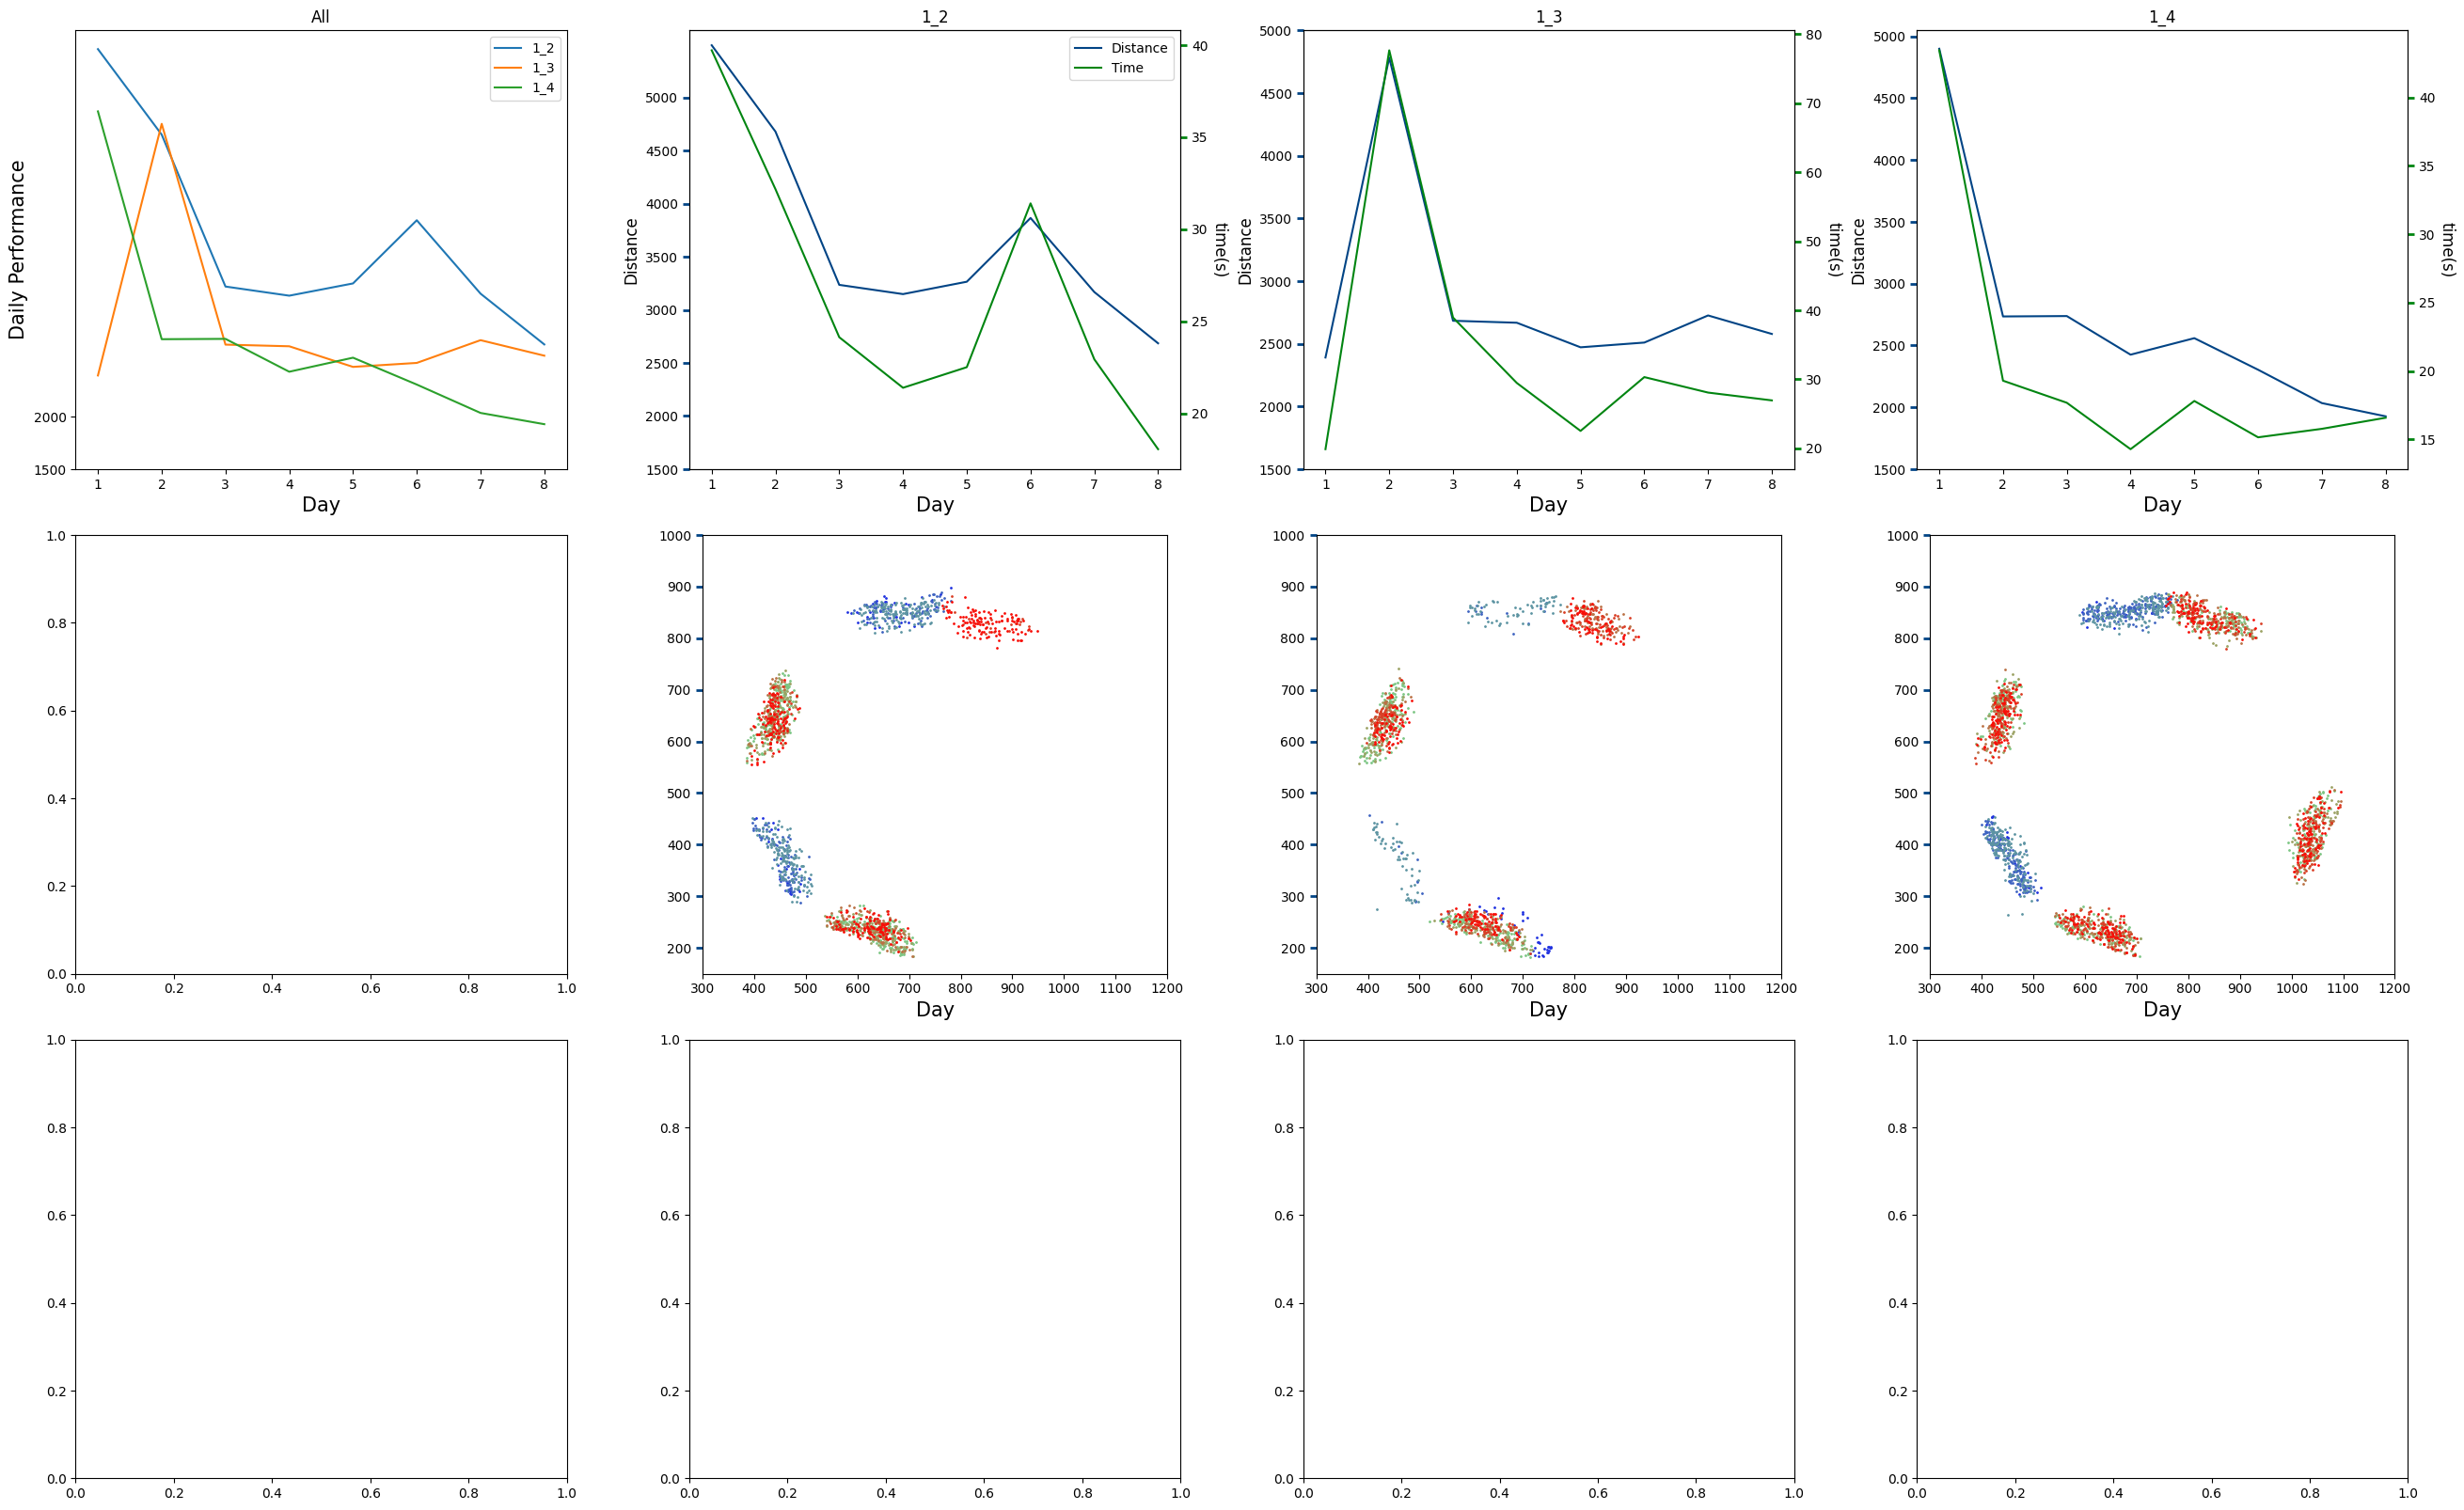

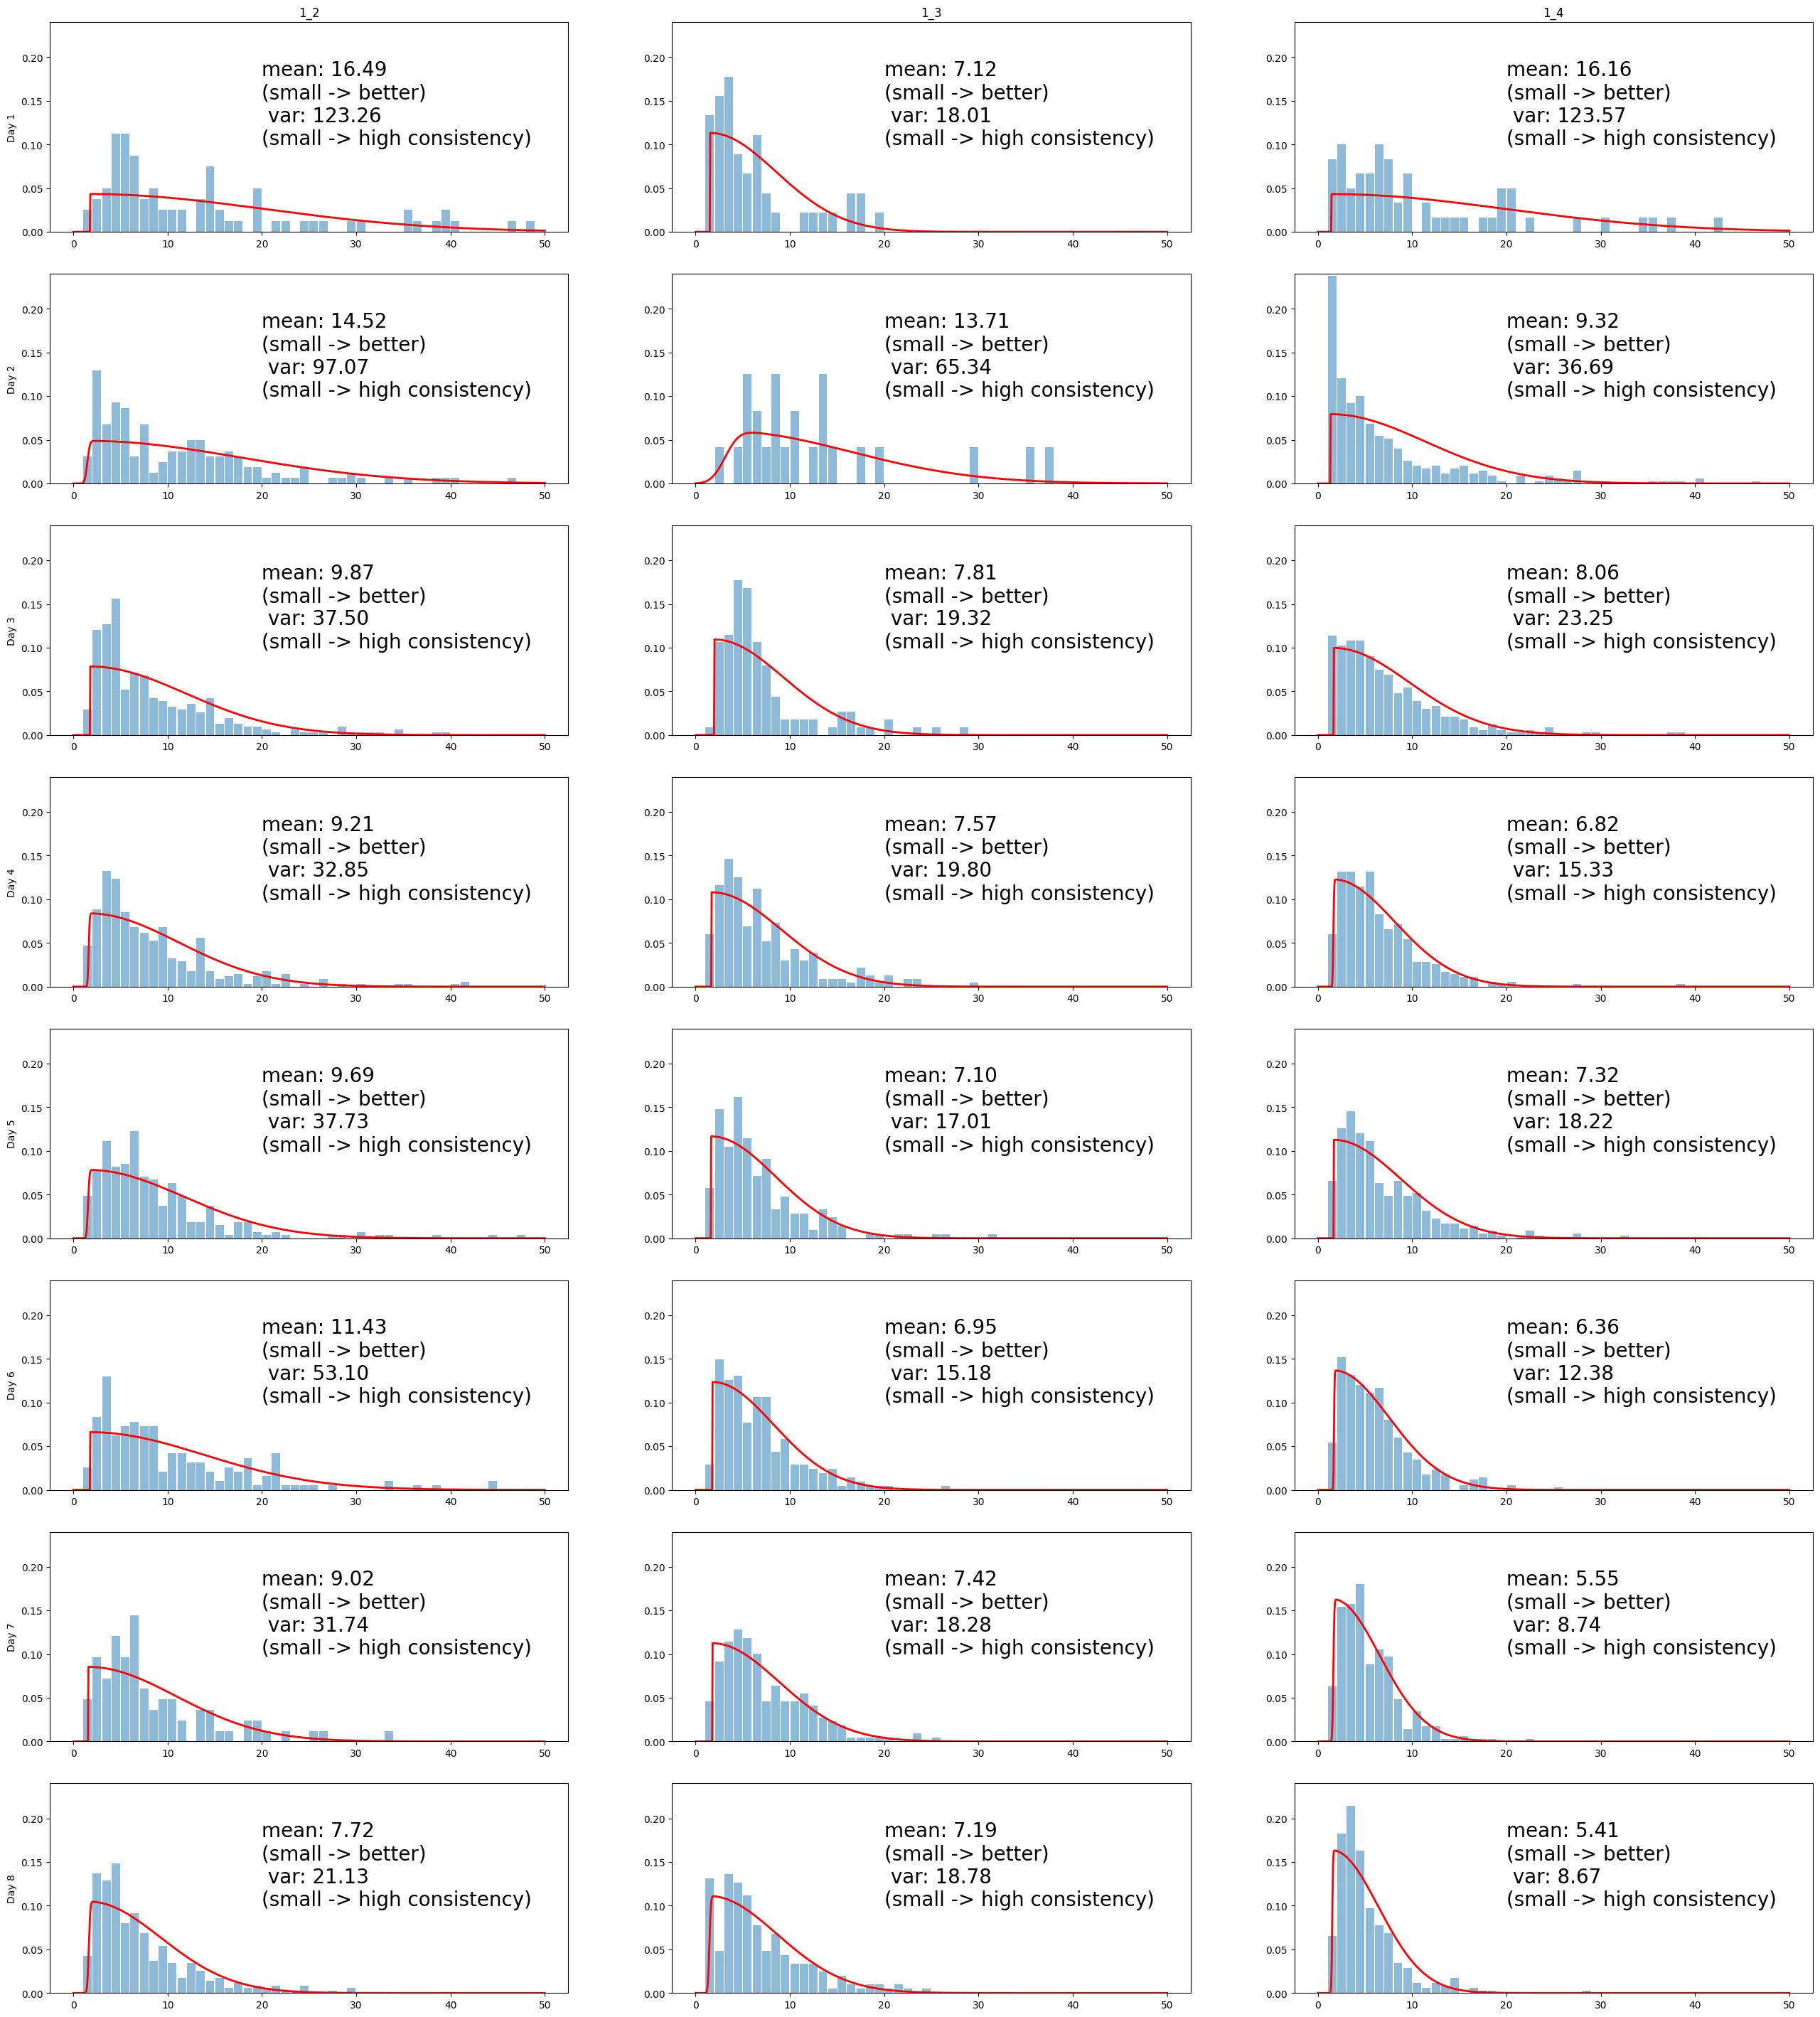

In [32]:
from sklearn.cluster import KMeans, DBSCAN
from scipy.spatial.distance import cdist
from scipy.stats import skewnorm

def cluster_list(data, n_clusters=None):
    """
    对单个列表进行聚类，返回聚类中心。
    """
    data = np.array(data).reshape(-1, 1)  # 转换为二维数组
    if n_clusters is not None:
        # 使用 KMeans 聚类
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(data)
        centers = kmeans.cluster_centers_.flatten()
    else:
        # 使用 DBSCAN 聚类
        dbscan = DBSCAN(eps=10, min_samples=2)
        labels = dbscan.fit_predict(data)
        unique_labels = set(labels) - {-1}  # 忽略噪声点
        centers = np.array([data[labels == label].mean() for label in unique_labels])

    centers = [int(20 + center // 90 * 90) for center in centers]
    return np.sort(centers)

def align_features(all_centers):
    """
    对所有列表的特征值进行全局对齐，返回统一的特征值集合。
    """
    all_centers_flat = np.concatenate(all_centers).reshape(-1, 1)
    kmeans_global = KMeans(n_clusters=len(set(np.round(all_centers_flat.flatten(), decimals=0))), random_state=42)
    kmeans_global.fit(all_centers_flat)
    global_centers = np.sort(kmeans_global.cluster_centers_.flatten())
    return global_centers

def assign_to_global(list_centers, global_centers):
    """
    将列表的特征值映射到全局特征值集合。
    """
    assigned_centers = []
    for center in list_centers:
        closest_center = global_centers[np.argmin(cdist([[center]], global_centers.reshape(-1, 1)))]
        assigned_centers.append(closest_center)
    return np.unique(assigned_centers)

fig, axes = plt.subplots(3, len(mouseNames)+1, figsize = ((len(mouseNames)+1) * 8, 20))
fig.subplots_adjust(wspace=0.25, hspace=0.15)

nDays:int = np.max([len(MouseDailyRecordClass.Days) for MouseDailyRecordClass in MouseRecords])
DailyColor:list[str]=[]
for i in range(1, nDays + 1):
    tempcolor = i * (255 // nDays)
    DailyColor.append(f"#{tempcolor:02X}{(205 - abs(205 - int(tempcolor * 1.6))):02X}{(255 - tempcolor):02X}")

DistancesEverydayEveryMouse = []
TimeEverydayEveryMouse = []
for mouse in MouseRecords:
    DistancesEverydayEveryMouse.append(mouse.ReturnDistance())
    tempMean = []
    for meandict in mouse.ReturnMean():
        tempMean.append(meandict["trialElapsedTimeMean"])
    TimeEverydayEveryMouse.append(tempMean)

for DistancePerMouseInd in range(0, len(DistancesEverydayEveryMouse)):
    meanDistanceInTotal = []
    for resultPerDay in DistancesEverydayEveryMouse[DistancePerMouseInd]:
        meanDistanceInTotal.append(np.sum(resultPerDay) / len(resultPerDay))

    tempAxe = axes[0][DistancePerMouseInd + 1]
    _ap, = tempAxe.plot(meanDistanceInTotal, label = "Distance", c = '#014485')
    # tempAxe.plot(np.ones(len(AccuracyInTotal)), linestyle = "--", c = "r")
    # tempAxe.set_ylim(0.5, 1.0)
    tempAxe.tick_params('y', which = 'major', color = '#014485', width = 2, length = 5)
    # tempAxe.set_yticks([])
    tempAxe.set_title(mouseNames[DistancePerMouseInd])
    tempXticks = []
    for i in range(1, len(meanDistanceInTotal) + 1):
        tempXticks.append(str(i))
    tempAxe.set_xticks(range(len(meanDistanceInTotal)), tempXticks)
    tempAxe.set_yticks(np.arange(1500, 5500, 500), [f"{value}" for value in np.arange(1500, 5500, 500)])
    tempAxe.set_xlabel("Day", size = 15)
    tempAxe.set_ylabel("Distance", size = 12)

    # for _x in range(0, len(AccuracyInTotal)):
    #     tempAxe.annotate(f"{AccuracyInTotal[_x] * 100: .2f}%", (_x, AccuracyInTotal[_x]+0.03))

    axes[0][0].plot(meanDistanceInTotal)
    axes[0][0].set_xticks(range(len(meanDistanceInTotal)), tempXticks)
    axes[0][0].set_yticks(np.arange(1500, 2500, 500), [f"{value}" for value in np.arange(1500, 2500, 500)])


    axeTime = tempAxe.twinx()
    _tp, = axeTime.plot(TimeEverydayEveryMouse[DistancePerMouseInd], c = "#018511", label = "Time")
    axeTime.set_ylabel("time(s)", rotation = 270, labelpad = 15, size = 12)
    axeTime.tick_params('y', which = 'major', color = '#018511', width = 2, length = 5)


    if tempAxe == axes[0][1]:
        tempAxe.legend([_ap, _tp], [p.get_label() for p in [_ap, _tp]])

axes[0][0].set_ylabel("Daily Performance", rotation = 90, size = 15)
axes[0][0].set_xlabel("Day", size = 15)
# axes[0][0].set_ylim(0.5, 1.0)
axes[0][0].set_title("All")
axes[0][0].legend(mouseNames)


StayPosEverydayEveryMouse = []
StayPosDirectionEverydayEveryMouse = []
TrialPosMarkEverydayEveryMouse = []
TrialDistanceEverydayEveryMouse = []
TrialPerformanceEverydayEveryMouse = []

for mouse in MouseRecords:
    StayPosEverydayEveryMouse.append(mouse.ReturnTrialMark())
    TrialDistanceEverydayEveryMouse.append(mouse.ReturnDistance())
    # StayPosDirectionEverydayEveryMouse.append([])
    # TrialPosMarkEverydayEveryMouse.append([])

for StayPosPerMouseInd in range(0, len(StayPosEverydayEveryMouse)):
    StayPosDirectionEverydayEveryMouse.append([])
    TrialPosMarkEverydayEveryMouse.append([])
    StayPosPerDay = []
    EnterPosPerDay = []
    for resultPerDay in StayPosEverydayEveryMouse[StayPosPerMouseInd]:
        StayPosPerDay.append(   pd.DataFrame(([v[0] for v in resultPerDay])))
        EnterPosPerDay.append(  pd.DataFrame([(v[1]) for v in resultPerDay]))
        
    tempAxe:plt.Axes = axes[1][StayPosPerMouseInd + 1]
    # tempAxe2:plt.Axes = axes[2][StayPosPerMouseInd + 1]
    
    for day in range(len(EnterPosPerDay)):
        # StayPosDirectionEverydayEveryMouse[StayPosPerMouseInd].append([])
        # TrialPosMarkEverydayEveryMouse[StayPosPerMouseInd].append([])
        
        x = EnterPosPerDay[day]['x'].values
        y = 1080 - np.array(EnterPosPerDay[day]['y'].values)
        StayPosDirectionEverydayEveryMouse[StayPosPerMouseInd].append(np.array(np.degrees(np.arctan2(np.array(y) - sceneinfo[1], np.array(x) - sceneinfo[0])) % 360))
        # TrialPosMarkEverydayEveryMouse.append([])

        _ap = tempAxe.scatter(x, y, c = DailyColor[day], s=1)
        # tempAxe2.scatter([day] * len(x), StayPosDirectionEverydayEveryMouse[StayPosPerMouseInd][day], c = DailyColor[day], s=1)

    # tempAxe.plot(np.ones(len(AccuracyInTotal)), linestyle = "--", c = "r")
    tempAxe.set_ylim(150, 1000)
    tempAxe.set_xlim(300, 1200)
    tempAxe.set_aspect(1)

    tempAxe.tick_params('y', which = 'major', color = '#014485', width = 2, length = 5)
    # tempAxe.set_yticks([])
    # tempAxe.legend([_ap, _tp], [p.get_label() for p in [_ap, _tp]])

    # tempAxe.set_xticks(range(len(meanDistanceInTotal)), [str(i) for i in range(1, len(meanDistanceInTotal) + 1)])
    # tempAxe.set_yticks(np.arange(1500, 5500, 500), [f"{value}" for value in np.arange(1500, 5500, 500)])
    tempAxe.set_xlabel("Day", size = 15)
    # tempAxe.set_ylabel("Distance", size = 12)
plt.show()


fig, axes = plt.subplots(nDays, len(mouseNames), figsize = ((len(mouseNames)+1) * 8, nDays*4.5))
fig.subplots_adjust(wspace=0.2, hspace=0.2)

tempList = [item for dirList in StayPosDirectionEverydayEveryMouse for item in dirList]
listCenters = [cluster_list(lst, n_clusters=None) for lst in tempList]
TrialPosMarks = list(set([item for dirList in listCenters for item in dirList]))
TrialPosMarks.sort()
def ProjectTrialPosMark(day, dir):
    if day <= 2:
        dir -= 50
    abs_diff = np.abs(np.array(TrialPosMarks) - dir[:, np.newaxis])
    # Find the index of the minimum differences
    closest_indices = np.argmin(abs_diff, axis=1)
    # Return the closest values using the indices
    return np.array(TrialPosMarks)[closest_indices]
    # return min(TrialPosMarks, key=lambda x: abs(x - dir))

for StayPosPerMouseInd in range(0, len(StayPosEverydayEveryMouse)):
    for day in range(len(StayPosEverydayEveryMouse[StayPosPerMouseInd])):
        TrialPosMarkEverydayEveryMouse[StayPosPerMouseInd].append(ProjectTrialPosMark(day, StayPosDirectionEverydayEveryMouse[StayPosPerMouseInd][day]))

TrialDistanceRatioEverydayEveryMouse = []
for mouseInd in range(len(MouseRecords)):
    TrialPerformanceEverydayEveryMouse.append([])
    TrialDistanceRatioEverydayEveryMouse.append([])
    for day in range(len(MouseRecords[mouseInd].Days)):
 
        data = np.array(TrialDistanceEverydayEveryMouse[mouseInd][day]) / sceneinfo[2]
        TrialDistanceRatioEverydayEveryMouse[mouseInd].append(data)
        shape, loc, scale = skewnorm.fit(data)
        TrialPerformanceEverydayEveryMouse[mouseInd].append([shape, loc, scale])

        tempAxe:plt.Axes = axes[day][mouseInd]
        tempAxe.hist(data, range=(0, 50), bins=50, alpha=0.5, density=True, rwidth= 0.9, label='Distances ratio')
        x = np.linspace(0, 50, 1000)
        pdf = skewnorm.pdf(x, a=shape, loc=loc, scale=scale)
        tempAxe.plot(x, pdf, 'r-', lw=2, label='Theoretical Skew Normal')

        mean = skewnorm.stats(shape, loc=loc, scale=scale, moments='m')  # 期望值
        var = skewnorm.stats(shape, loc=loc, scale=scale, moments='v')   # 方差
        tempAxe.annotate(f"mean: {mean:.2f}\n(small -> better)\n var: {var:.2f}\n(small -> high consistency)", (20, 0.1), size=20)

    
        if day == 0:
            tempAxe.set_title(mouseNames[mouseInd])
        if mouseInd == 0:
            tempAxe.set_ylabel(f"Day {day+1}")

        tempAxe.set_ylim(0, 0.24)

plt.show()


mouse 0 day 0 done
mouse 0 day 1 done
mouse 0 day 2 done
mouse 0 day 3 done
mouse 0 day 4 done
mouse 0 day 5 done
mouse 0 day 6 done
mouse 0 day 7 done
mouse 1 day 0 done
mouse 1 day 1 done
mouse 1 day 2 done
mouse 1 day 3 done
mouse 1 day 4 done
mouse 1 day 5 done
mouse 1 day 6 done
mouse 1 day 7 done
mouse 2 day 0 done
mouse 2 day 1 done
mouse 2 day 2 done
mouse 2 day 3 done
mouse 2 day 4 done
mouse 2 day 5 done
mouse 2 day 6 done
mouse 2 day 7 done


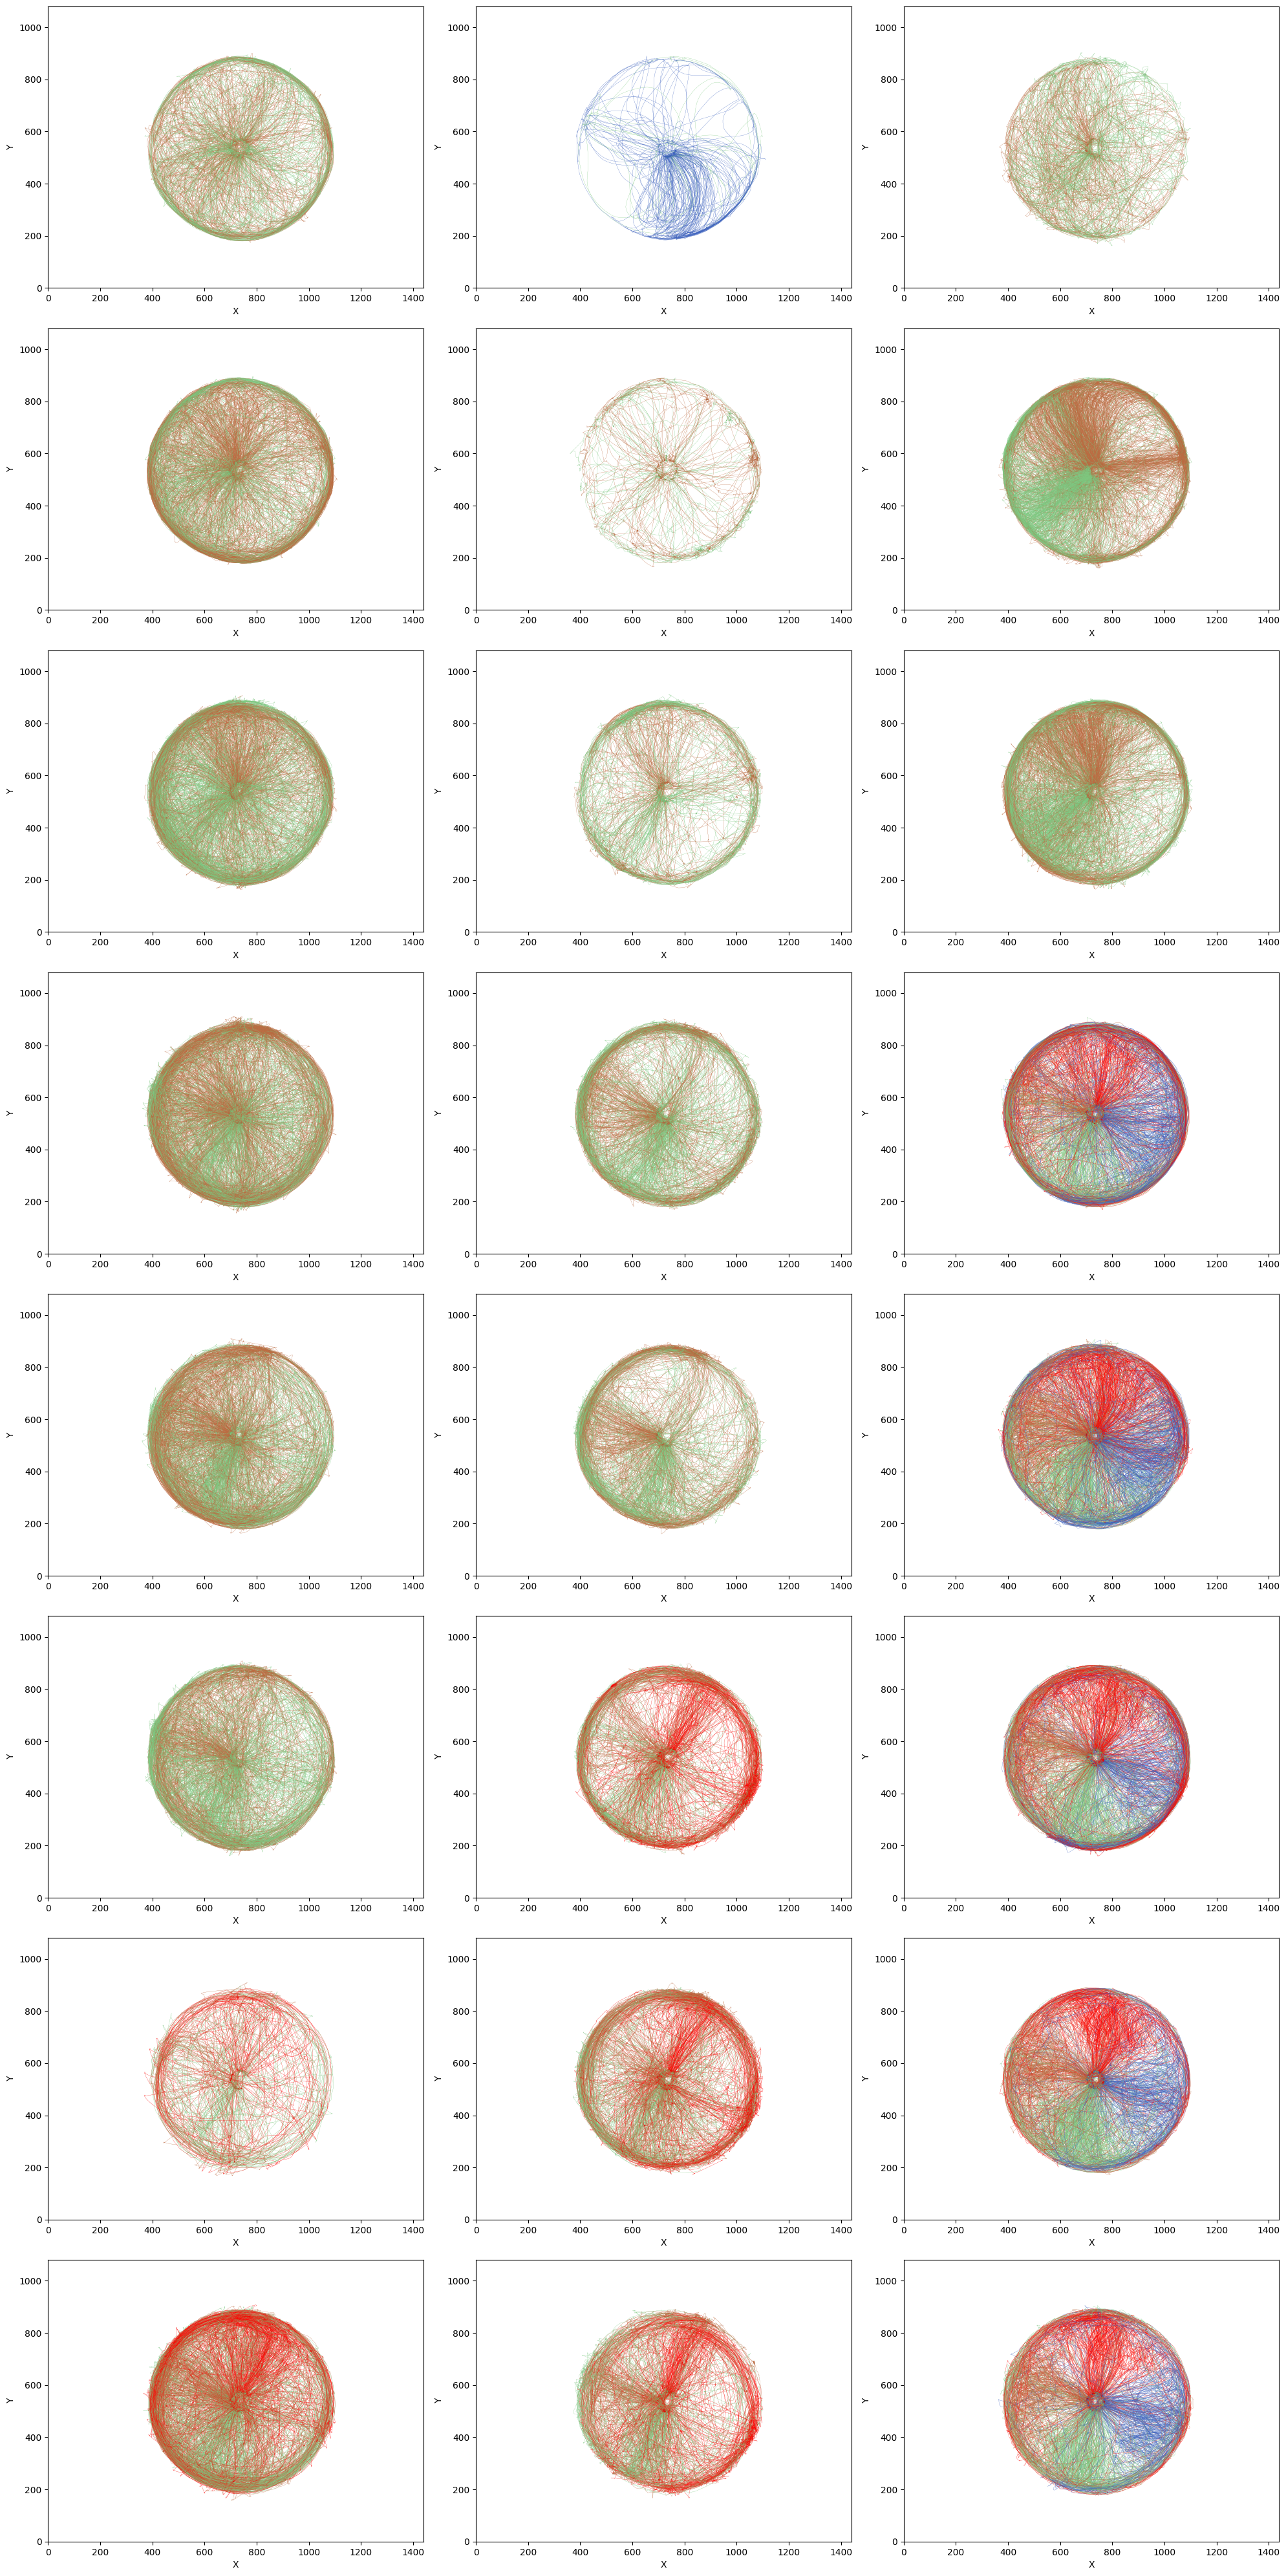

In [31]:
nDays:int = np.max([len(MouseDailyRecordClass.Days) for MouseDailyRecordClass in MouseRecords])
DailyColor:list[str]=[]
for i in range(1, nDays + 1):
    tempcolor = i * (255 // nDays)
    DailyColor.append(f"#{tempcolor:02X}{(205 - abs(205 - int(tempcolor * 1.6))):02X}{(255 - tempcolor):02X}")

MarkColor:list[str]=[]
for i in range(1, len(TrialPosMarks) + 1):
    tempcolor = i * (255 // len(TrialPosMarks))
    MarkColor.append(f"#{tempcolor:02X}{(205 - abs(205 - int(tempcolor * 1.6))):02X}{(255 - tempcolor):02X}")

fig, axes = plt.subplots(nDays, len(mouseNames), figsize = ((len(mouseNames)+1) * 5, nDays*5))
fig.subplots_adjust(wspace=0.2, hspace=0.2)



# print([assign_to_global(centers, align_features(listCenters)) for centers in listCenters])
PosEverydayEveryMouse = []
for mouse in MouseRecords:
    PosEverydayEveryMouse.append(mouse.ReturnPos())

for mouseInd in range(len(MouseRecords)):
    for day in range(len(MouseRecords[mouseInd].Days)):
        tempAxe:plt.Axes = axes[day][mouseInd]
        tempdf:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
        for i in range(len(tempdf)):
            # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
            # fig.savefig("tempAxe.png", dpi = 200)
            points = np.array([tempdf[i]['smooth_x'].values, tempdf[i]['smooth_y'].values]).T.reshape(-1, 1, 2)
            segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)

            # 创建颜色映射
            # norm = plt.Normalize(0, 360, clip=True)
            # lc = LineCollection(segments_vis, cmap='viridis', norm=norm, linewidth=0.2)
            # colors = [DailyColor[mark] for mark in TrialPosMarks.index(TrialPosMarkEverydayEveryMouse[mouseInd][day][i])]
            lc:LineCollection = LineCollection(segments_vis, colors = MarkColor[TrialPosMarks.index(TrialPosMarkEverydayEveryMouse[mouseInd][day][i])], linewidth=0.2)
            # lc.set_array(np.array([TrialPosMarkEverydayEveryMouse[mouseInd][day][i]]*len(tempdf)))
            # 绘制轨迹
            tempAxe.add_collection(lc)

        print(f'mouse {mouseInd} day {day} done')
        tempAxe.set_xlim(0, 1440)
        tempAxe.set_ylim(0, 1080)
        tempAxe.set_aspect(1)
        tempAxe.set_xlabel('X')
        tempAxe.set_ylabel('Y')
        # tempAxe.set_title('')
        plt.tight_layout()
        # fig.colorbar(lc, ax=tempAxe)
    
plt.show()



mouse 0 mark 0 done
mouse 0 mark 1 done
mouse 0 mark 2 done
mouse 0 mark 3 done


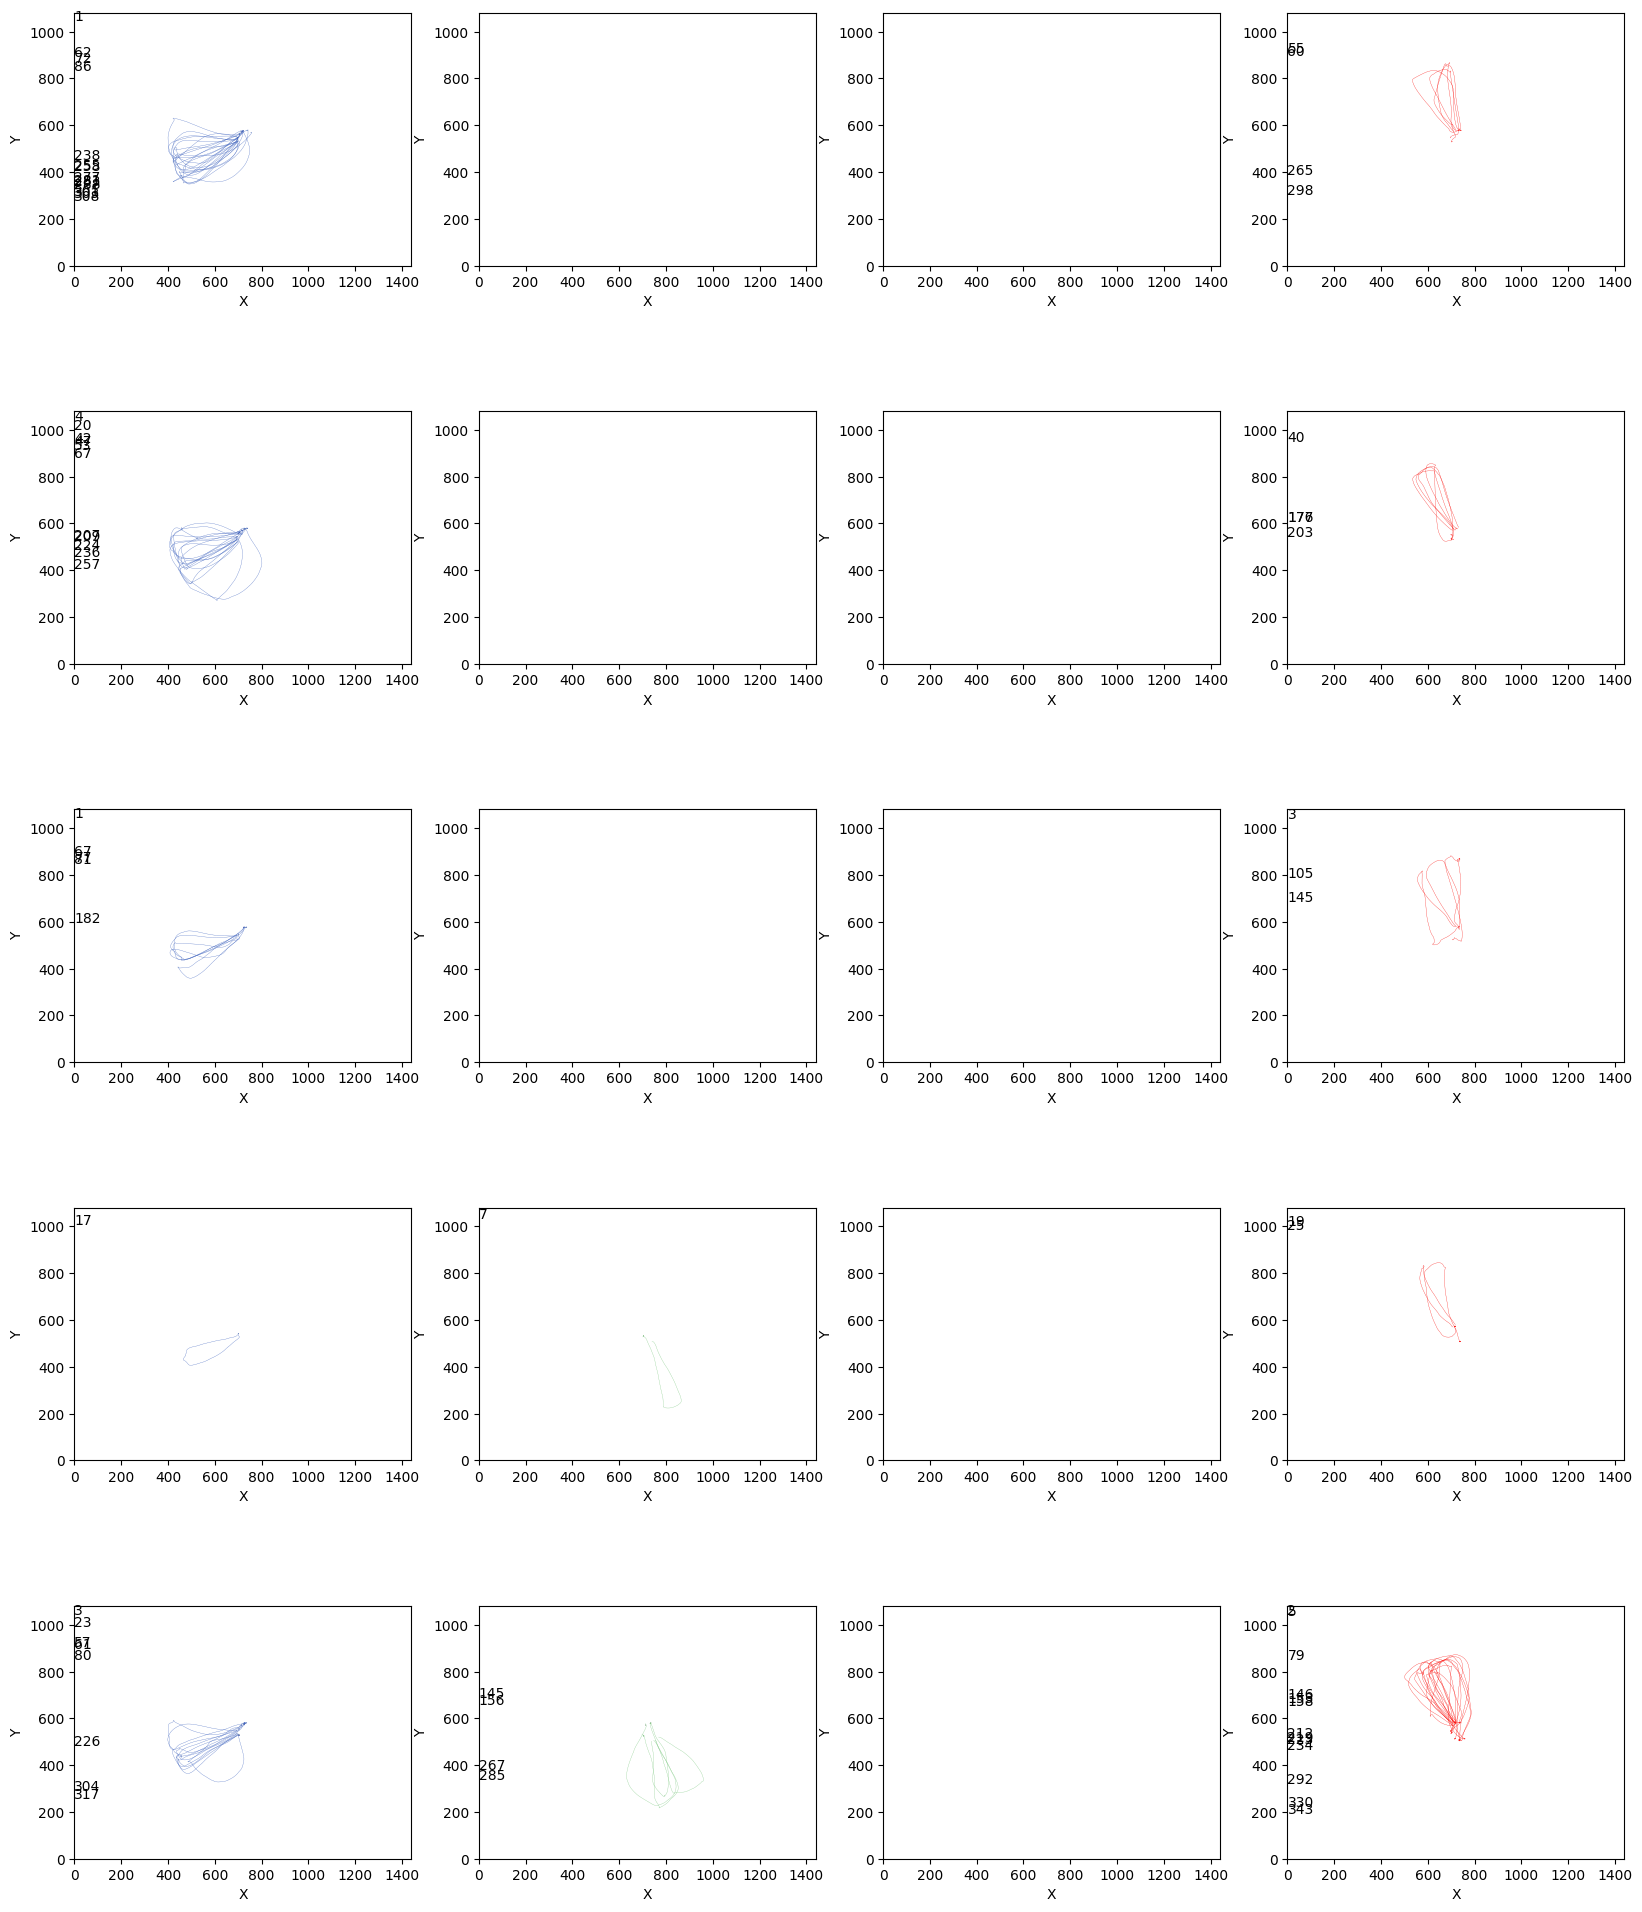

mouse 1 mark 0 done
mouse 1 mark 1 done
mouse 1 mark 2 done
mouse 1 mark 3 done


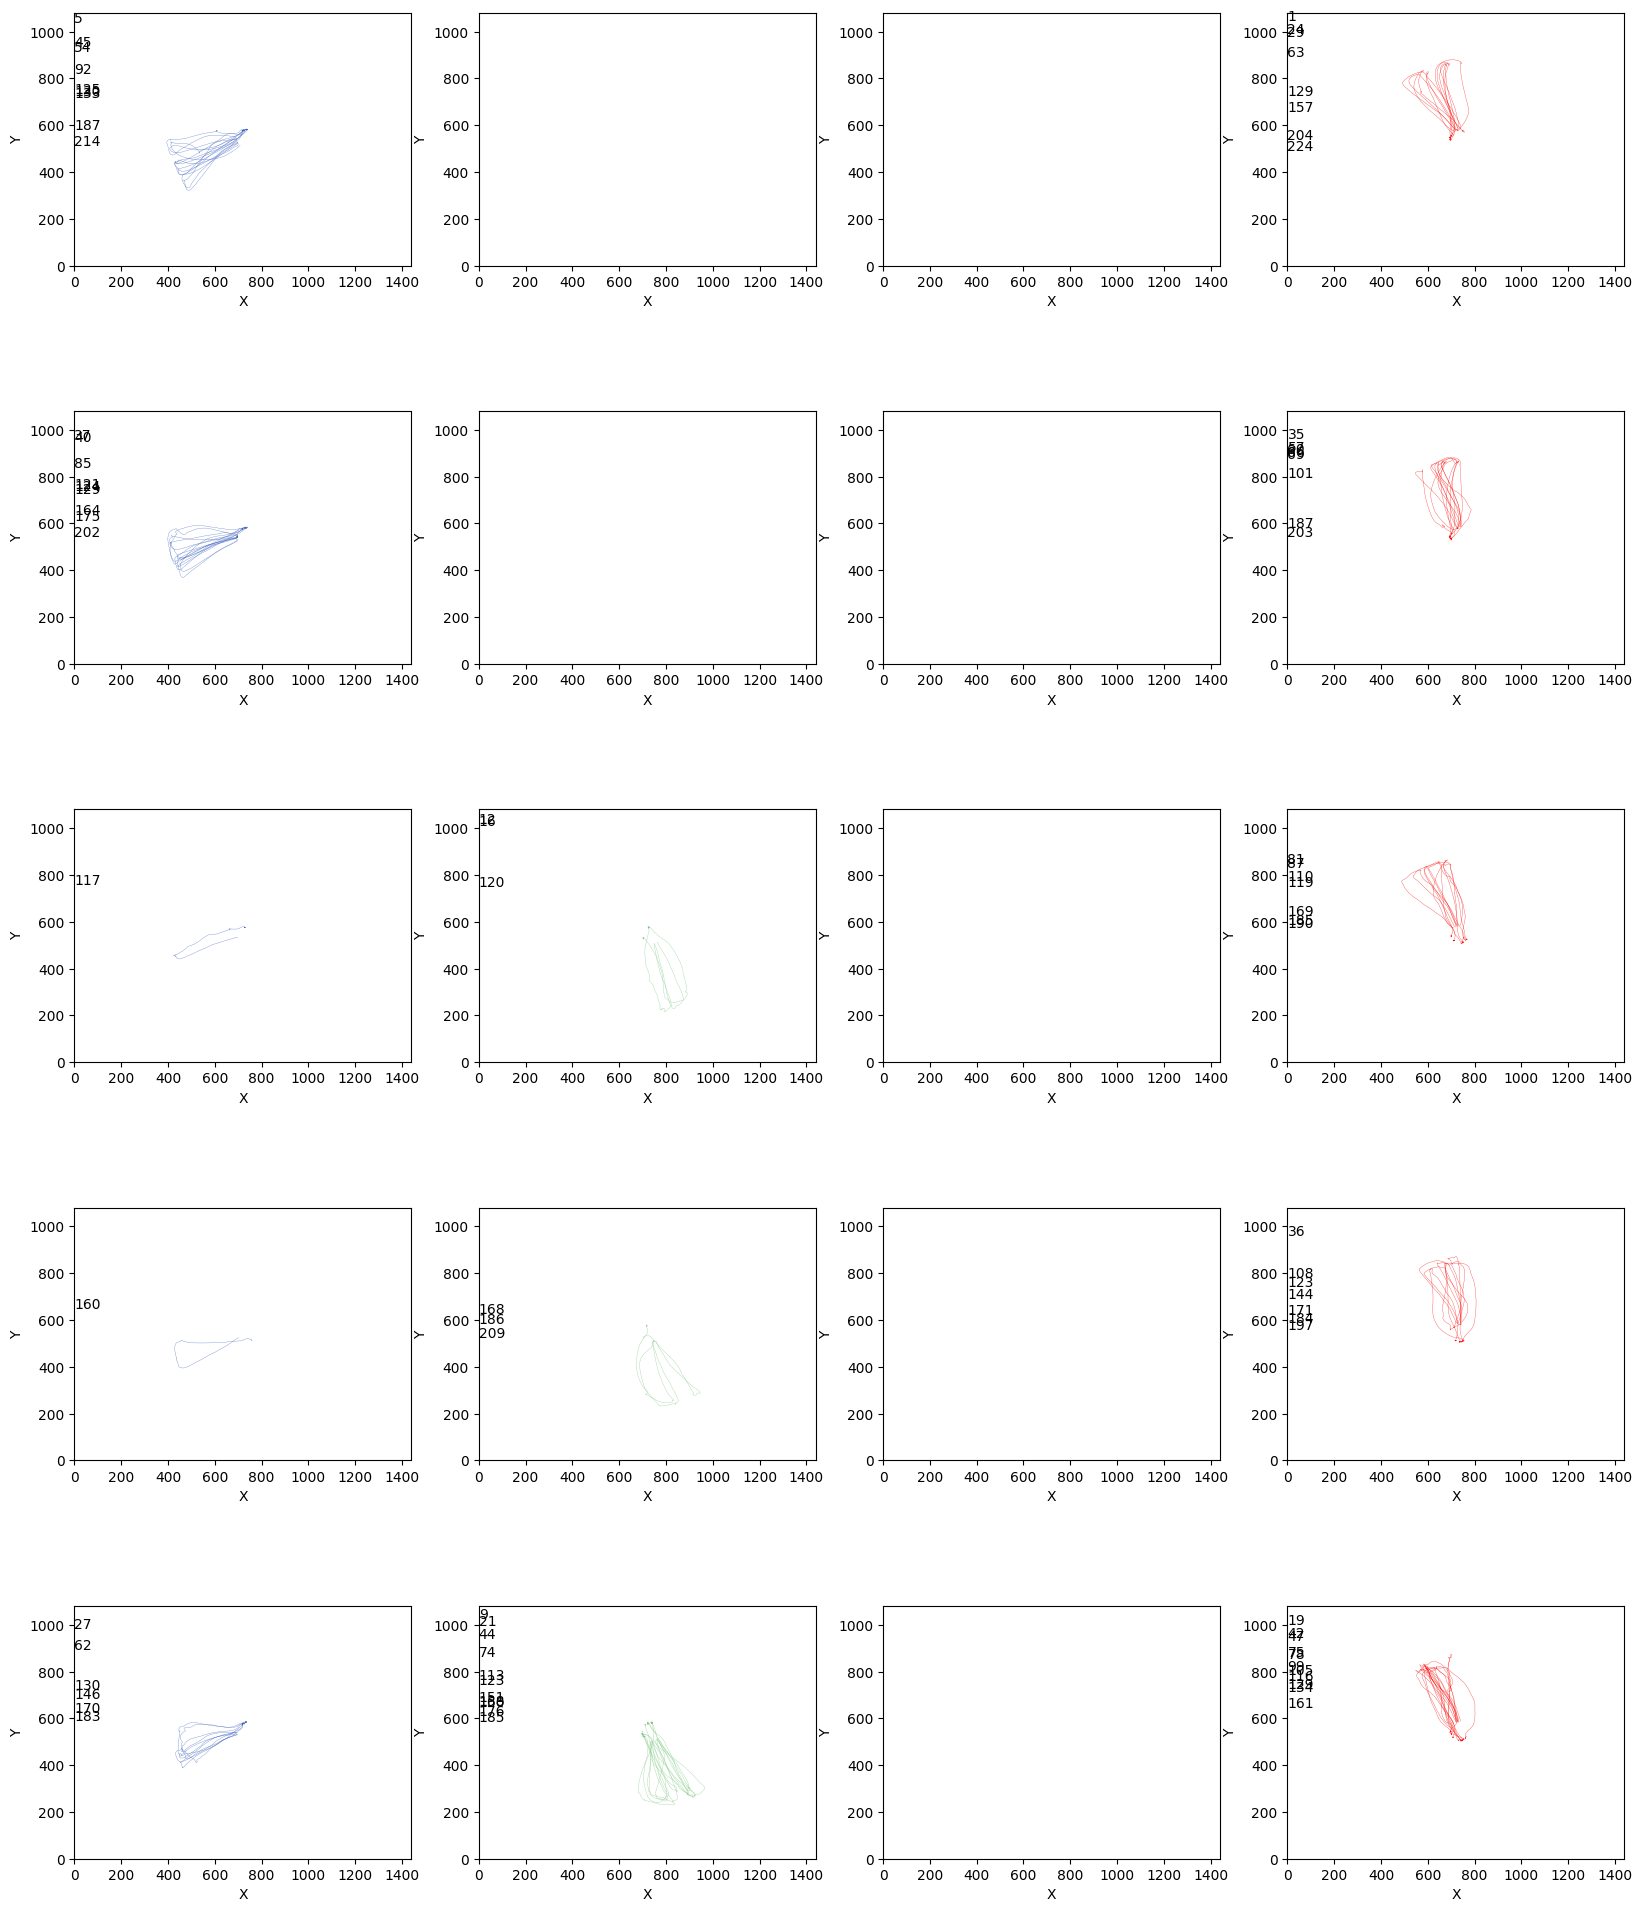

mouse 2 mark 0 done
mouse 2 mark 1 done
mouse 2 mark 2 done
mouse 2 mark 3 done


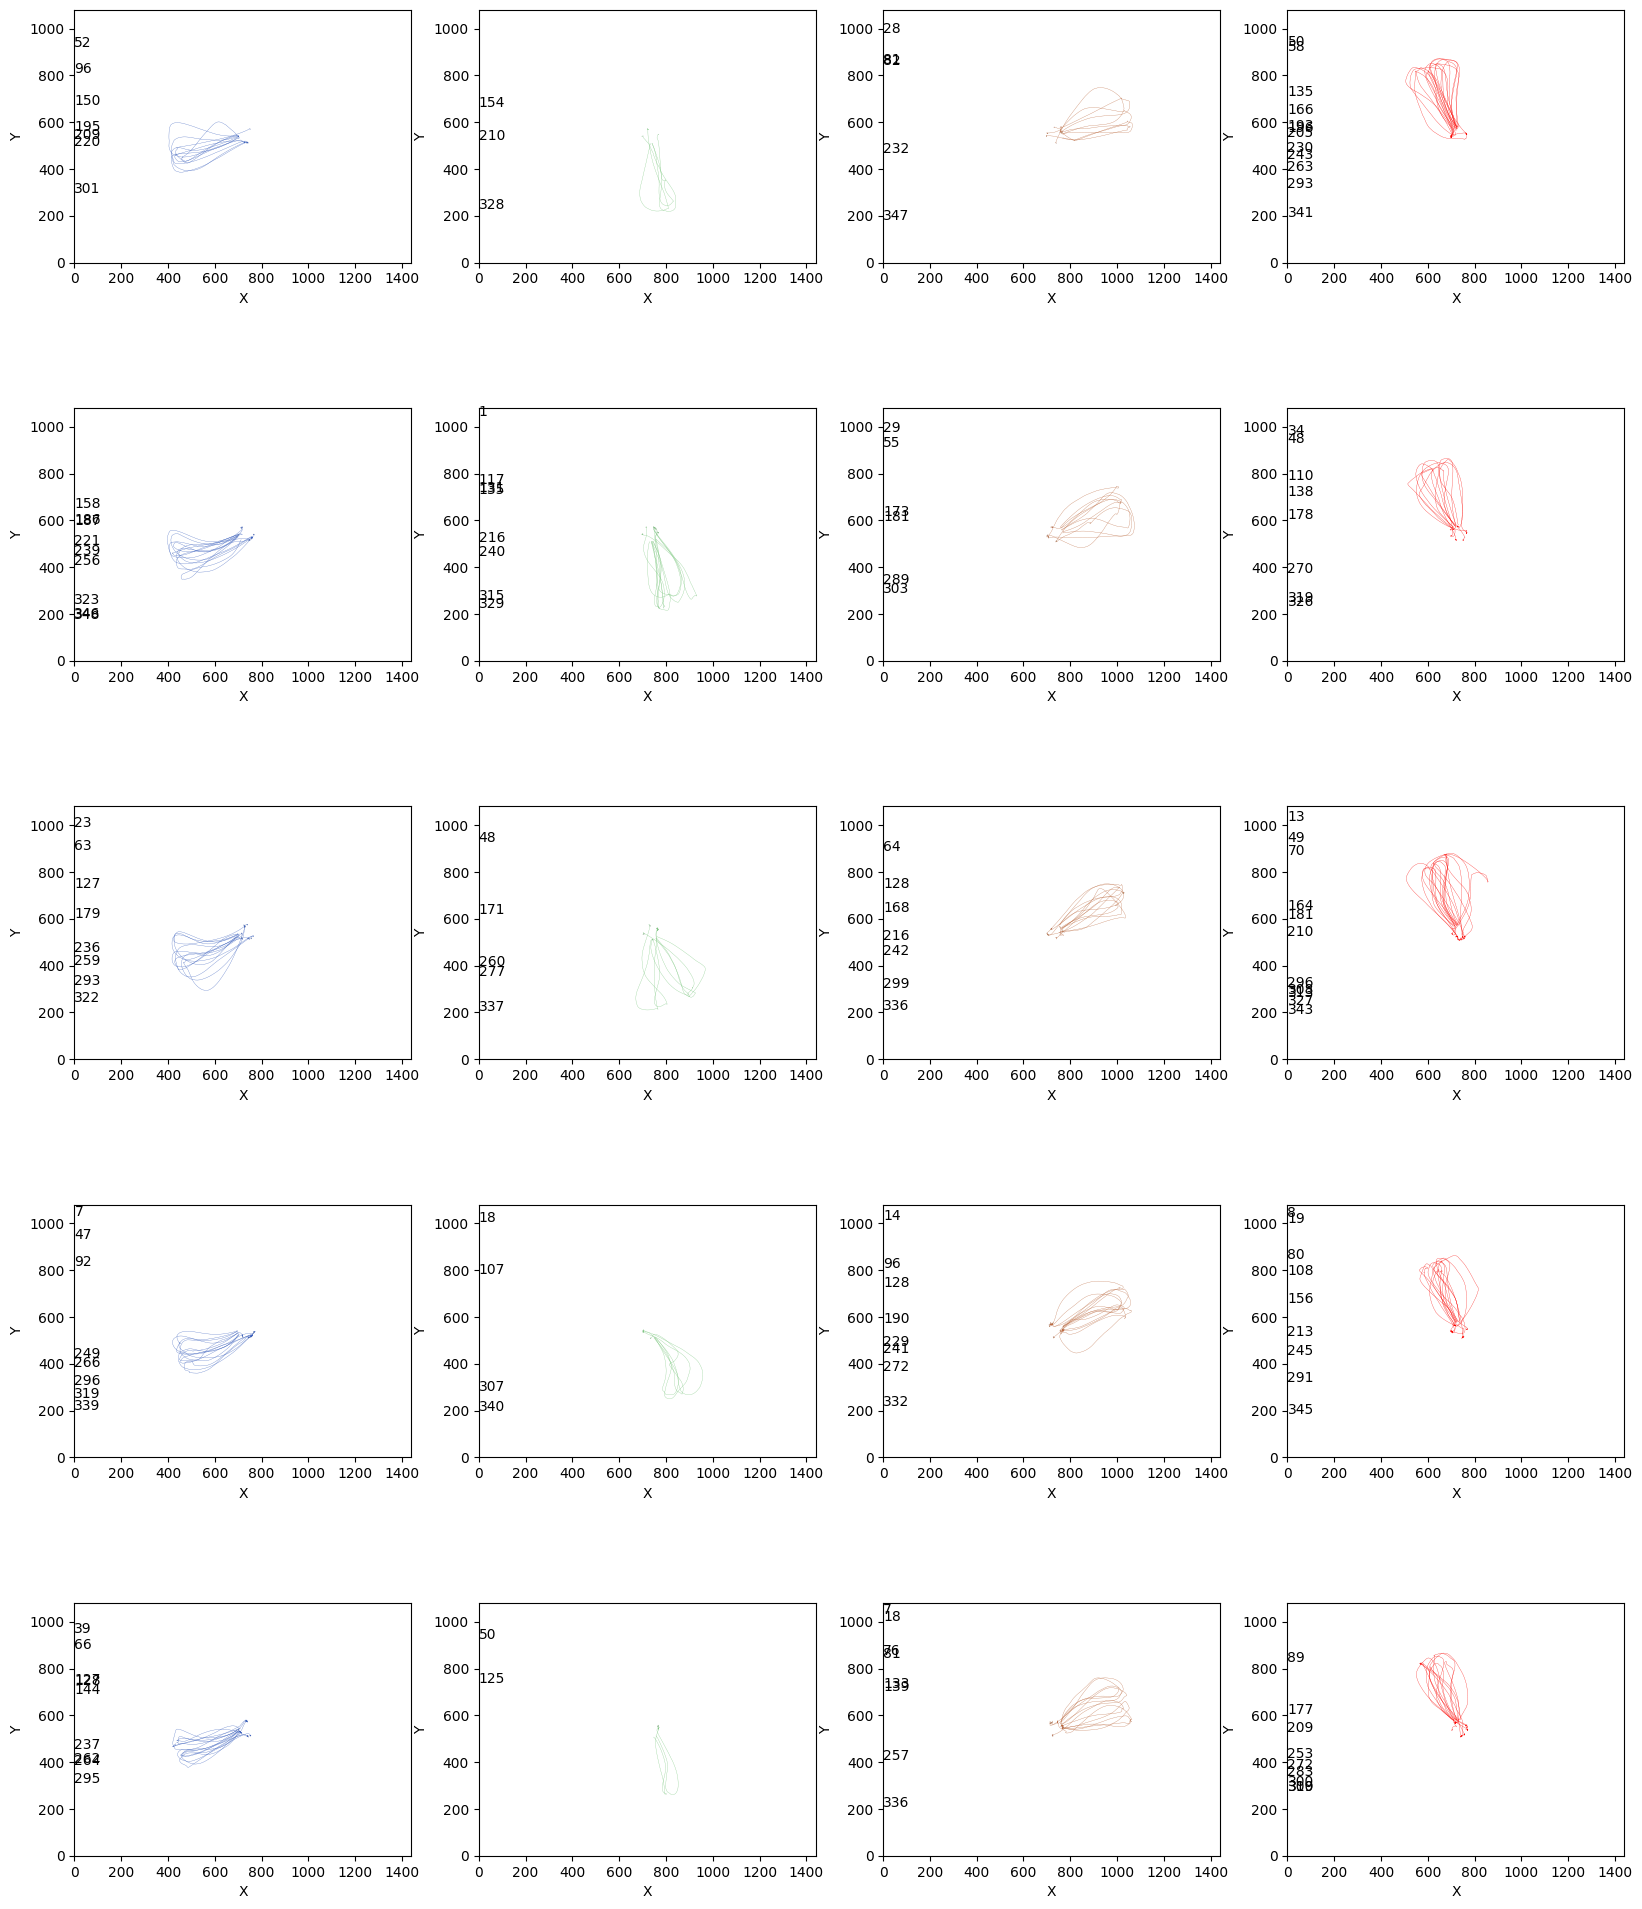

In [25]:
certainMarkEverydayEveryMouse = []
for mouseInd in range(len(MouseRecords)):
    certainMarkEverydayEveryMouse.append([])
    for mark in range(len(TrialPosMarks)):
        certainMarkEverydayEveryMouse[mouseInd].append([])
        for day in range(len(MouseRecords[mouseInd].Days)):
            certainMarkEverydayEveryMouse[mouseInd][mark].append([])
            tempLs = TrialPosMarkEverydayEveryMouse[mouseInd][day]
            certainMarkEverydayEveryMouse[mouseInd][mark][day].append(np.array(range(0, len(tempLs)))[tempLs == TrialPosMarks[mark]])

for mouseInd in range(len(MouseRecords)):
    fig, axes = plt.subplots(nDays - 3, 4, figsize = (4 * 5, (nDays - 3)*5))
    fig.subplots_adjust(wspace=0.2, hspace=0.2)

    for axe in axes.flatten():
        axe.set_xlim(0, 1440)
        axe.set_ylim(0, 1080)
        axe.set_aspect(1)
        axe.set_xlabel('X')
        axe.set_ylabel('Y')
    for mark in range(len(TrialPosMarks)):
        for day in range(3, len(MouseRecords[mouseInd].Days)):
            tempdf:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
            if len(certainMarkEverydayEveryMouse[mouseInd][mark][day]):
                for i in certainMarkEverydayEveryMouse[mouseInd][mark][day][0]:
                    if TrialDistanceRatioEverydayEveryMouse[mouseInd][day][i] < 2.1:
                # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
                # fig.savefig("tempAxe.png", dpi = 200)
                        points = np.array([tempdf[i]['smooth_x'].values, tempdf[i]['smooth_y'].values]).T.reshape(-1, 1, 2)
                        segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)
                        lc:LineCollection = LineCollection(segments_vis, colors = MarkColor[mark], linewidth=0.2)
                        axes[day-3][mark].add_collection(lc)
                        axes[day-3][mark].annotate(str(i), (0,1050 - i * 2.5))
        print(f"mouse {mouseInd} mark {mark} done")
    plt.show()

# for mouseInd in range(len(MouseRecords)):
#     for day in range(3, len(MouseRecords[mouseInd].Days)):
#         tempAxe:plt.Axes = axes[day][mouseInd]
#         tempdf:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
#         for i in range(len(tempdf)):
#             # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
#             # fig.savefig("tempAxe.png", dpi = 200)
#             DrawTrack(tempdf[i]['smooth_x'].values, tempdf[i]['smooth_y'].values, addInfo=f'{mouseInd}_{day}_{TrialDistanceRatioEverydayEveryMouse[mouseInd][day][i]:.2f}_trial{i}', show=False, save=True, lw=0.6, pointSize=0.3)
                

# for mouseInd in range(len(MouseRecords)):
#     for mark in range(len(TrialPosMarks)):
#         for day in range(3, len(MouseRecords[mouseInd].Days)):
#             tempdf:list[pd.DataFrame] = PosEverydayEveryMouse[mouseInd][day]
#             if len(certainMarkEverydayEveryMouse[mouseInd][mark][day]):
#                 for i in certainMarkEverydayEveryMouse[mouseInd][mark][day][0]:
#                     if TrialDistanceRatioEverydayEveryMouse[mouseInd][day][i] < 4:
#                 # DrawTrack(tempdf[i]['x'].values, tempdf[i]['y'].values, TrialPosMarkEverydayEveryMouse[mouseInd][day][i], addInfo=f'mouse_{mouseInd}_day_{day}', show=False, save=True)
#                 # fig.savefig("tempAxe.png", dpi = 200)
#                         # points = np.array([tempdf[i]['smooth_x'].values, tempdf[i]['smooth_y'].values])
#                         DrawTrack(tempdf[i]['smooth_x'].values, tempdf[i]['smooth_y'].values, show=False, save=True, addInfo=f'{mouseInd}_{mark}_{day}_{TrialDistanceRatioEverydayEveryMouse[mouseInd][day][i]}', lw=0.4)
#                         # segments_vis = np.concatenate([points[:-1], points[1:]], axis=1)
#                         # lc:LineCollection = LineCollection(segments_vis, colors = MarkColor[mark], linewidth=0.2)
#         print(f"mouse {mouseInd} mark {mark} done")
            